# Co-occurrence Component OLS Regression — Raw Growth Rate (no SPO reference)

Same analysis as `co_occurrence_component_ols_regression.ipynb` but the target is
the **raw component-mean growth rate** (ppm/yr), without subtracting the South Pole
reference.  This lets you see the absolute CO₂ growth-rate level in each component
rather than the local anomaly relative to background.

Two models are compared:

| Model | Predictors |
|-------|-----------|
| **A** | Standardized emission + global SOI (lagged 7 months) |
| **B** | Standardized emission + component-mean GOSIF |

Results are compared with the per-grid-cell output from
`gridpoint_co2_regression_ols_emission_soi_lag7v2.ipynb`.


In [17]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


## 1. Configuration

In [ ]:
# ── File paths ──────────────────────────────────────────────────────────────
NC_FILE   = Path("/merged_co-occurrance-clusters.nc")
SOI_FILE  = Path("/soi.txt")

# Fallbacks if the SOI file has a different name
if not SOI_FILE.exists():
    for _cand in [Path("/mnt/data/Pegado text(9).txt"), Path("Pegado text(9).txt"),
                  Path("Pegado text.txt")]:
        if _cand.exists():
            SOI_FILE = _cand
            break

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

# ── Analysis settings ────────────────────────────────────────────────────────
COMPONENTS     = [f"component_{i}" for i in range(1, 6)]
TARGET_VAR     = "growth_rate"
EMISSION_VAR   = "emission"
GOSIF_VAR      = "gosif"
# SPO_LAT_MAX removed — this notebook uses the raw (unreferenced) growth rate
MIN_OBS        = 6
SOI_LAG_MONTHS = 7          # CO2 growth-rate response lags SOI by ~7 months

# ── Aesthetics ────────────────────────────────────────────────────────────────
COMP_COLORS = {
    "component_1": "#e41a1c",
    "component_2": "#377eb8",
    "component_3": "#4daf4a",
    "component_4": "#ff7f00",
    "component_5": "#984ea3",
}
COMP_LABELS = {c: f"C{i+1}" for i, c in enumerate(COMPONENTS)}

HAS_SOI = SOI_FILE.exists()
print(f"NC file : {NC_FILE}")
print(f"SOI file: {SOI_FILE}  →  {'FOUND — Model A will run' if HAS_SOI else 'NOT FOUND — Model A (emission+SOI) will be skipped'}")


NC file : Datasets/merged_co-occurrance-clusters.nc
SOI file: Datasets/SOI.txt  →  FOUND — Model A will run


## 2. Load the merged dataset

In [19]:
ds    = xr.open_dataset(NC_FILE)
years = ds["time"].values.astype(int)
lats  = ds["lat"].values
lons  = ds["lon"].values
print(ds)
print(f"\nYears ({len(years)}): {years}")
print("\nComponent coverage (% cells == 1 vs all finite cells, pooled across years):")
for comp in COMPONENTS:
    total  = int(np.isfinite(ds[comp]).sum())
    active = int((ds[comp] == 1.0).sum())
    print(f"  {COMP_LABELS[comp]}: {active:,} cell-years  ({100*active/total:.1f}% of finite)")


<xarray.Dataset> Size: 41MB
Dimensions:         (lat: 180, lon: 360, time: 10, longitude: 360, latitude: 180)
Coordinates:
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * time            (time) int64 80B 2015 2016 2017 2018 ... 2021 2022 2023 2024
  * longitude       (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * latitude        (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
Data variables: (12/13)
    growth_rate     (time, lat, lon) float64 5MB ...
    emission        (time, lat, lon) float32 3MB ...
    gosif           (time, lat, lon) float32 3MB ...
    delta_emission  (time, lat, lon) float32 3MB ...
    delta_gosif     (time, lat, lon) float32 3MB ...
    cams_xco2       (time, latitude, longitude) float32 3MB ...
    ...              ...
    mean_co2        (time, lat, lon) float64 5MB ...
    component_1     (time, lat, lon) float

## 3. Read and lag the SOI index (Model A only)

Monthly SOI is shifted forward by 7 months so that each annual average corresponds to
the ENSO conditions that drove the CO₂ response in that year.  
e.g. CO₂ year 2015 uses SOI months from ~June 2014 → May 2015.


In [20]:
def read_standardized_soi(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"SOI file not found at {path}.\n"
            "Place SOI.txt next to the notebook, or update SOI_FILE in the config cell."
        )
    text = path.read_text(errors="ignore")
    if "STANDARDIZED" not in text:
        raise ValueError("STANDARDIZED section not found in SOI file.")
    std_text = text.split("STANDARDIZED", 1)[1]
    rows = []
    for line in std_text.splitlines():
        nums = re.findall(r"-?\d+(?:\.\d+)?", line)
        if len(nums) < 13:
            continue
        yr = int(float(nums[0]))
        if not (1800 <= yr <= 2200):
            continue
        for mo, val in enumerate([float(x) for x in nums[1:13]], start=1):
            rows.append({"date": pd.Timestamp(year=yr, month=mo, day=1),
                         "year": yr, "month": mo,
                         "soi": np.nan if float(val) <= -900 else float(val)})
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No SOI values parsed.")
    return df

if HAS_SOI:
    soi_monthly = read_standardized_soi(SOI_FILE)
    soi_monthly["co2_date"] = soi_monthly["date"] + pd.DateOffset(months=SOI_LAG_MONTHS)
    soi_monthly["co2_year"] = soi_monthly["co2_date"].dt.year
    soi_annual = (
        soi_monthly.groupby("co2_year")["soi"]
        .agg(soi_raw="mean", n_months="count")
        .reset_index()
    )
    soi_annual.loc[soi_annual["n_months"] < 12, "soi_raw"] = np.nan
    _by_yr   = soi_annual.set_index("co2_year")["soi_raw"]
    soi_raw  = np.array([_by_yr.loc[int(y)] for y in years], dtype=float)
    soi_mu   = float(np.nanmean(soi_raw))
    soi_sd   = float(np.nanstd(soi_raw))
    soi_z    = (soi_raw - soi_mu) / soi_sd
    print("Annual SOI (lagged 7 months, z-scored over 2015-2024):")
    for y, z in zip(years, soi_z):
        print(f"  {y}: {z:+.3f}")
    soi_matched = pd.DataFrame({"year": years, "soi_raw": soi_raw, "soi_z": soi_z})
    soi_matched.to_csv(OUTPUT_DIR / "co_occ_nospo_annual_soi_lag7.csv", index=False)
else:
    soi_z = None
    print("SOI not available — Model A will be skipped.")


Annual SOI (lagged 7 months, z-scored over 2015-2024):
  2015: -0.905
  2016: -1.798
  2017: +0.278
  2018: +0.567
  2019: -0.439
  2020: -0.640
  2021: +0.995
  2022: +1.410
  2023: +1.222
  2024: -0.691


## 4. Build component-year spatial means

For each component `c` and year `t`, spatially average `growth_rate`, `emission`, and
`gosif` over all grid cells where `component_c(t, lat, lon) == 1`.

> **Note:** cells can belong to multiple components simultaneously (fuzzy membership).


In [21]:
print("Computing component-year spatial means...\n")
comp_means  = {}   # {comp: {var: array(n_years)}}
comp_ncells = {}   # {comp: array(n_years)}

for comp in COMPONENTS:
    mask_c = (ds[comp] == 1.0)
    gr_c   = ds[TARGET_VAR].where(mask_c).mean(["lat","lon"], skipna=True).values.astype(float)
    em_c   = ds[EMISSION_VAR].where(mask_c).mean(["lat","lon"], skipna=True).values.astype(float)
    gf_c   = ds[GOSIF_VAR].where(mask_c).mean(["lat","lon"], skipna=True).values.astype(float)
    nc     = mask_c.sum(["lat","lon"]).values.astype(int)
    comp_means[comp]  = {"growth_rate": gr_c, "emission": em_c, "gosif": gf_c}
    comp_ncells[comp] = nc
    print(f"  {COMP_LABELS[comp]}: {nc.mean():.0f} cells/yr  "
          f"GR=[{gr_c.min():.3f}, {gr_c.max():.3f}]  "
          f"em=[{em_c.min():.3g}, {em_c.max():.3g}]  "
          f"gosif=[{gf_c.min():.4f}, {gf_c.max():.4f}]")

df_gr = pd.DataFrame({COMP_LABELS[c]: comp_means[c]["growth_rate"] for c in COMPONENTS},
                     index=years)
print("\nComponent-year mean growth rates (ppm/yr):")
print(df_gr.round(4).to_string())


Computing component-year spatial means...

  C1: 6777 cells/yr  GR=[2.093, 3.133]  em=[2.31, 3.41]  gosif=[-0.0181, 0.0057]
  C2: 4995 cells/yr  GR=[2.020, 3.245]  em=[150, 227]  gosif=[0.0221, 0.0260]
  C3: 2548 cells/yr  GR=[2.071, 3.292]  em=[4.38e+03, 5.07e+03]  gosif=[0.0223, 0.0257]
  C4: 2516 cells/yr  GR=[2.133, 3.366]  em=[7.84e+04, 8.41e+04]  gosif=[0.1494, 0.1615]
  C5: 1635 cells/yr  GR=[2.063, 3.448]  em=[6.28e+03, 7.44e+03]  gosif=[0.3187, 0.3300]

Component-year mean growth rates (ppm/yr):
         C1     C2     C3     C4     C5
2015 2.1370 2.4178 2.4173 2.4944 3.0002
2016 2.8685 2.9883 3.0688 3.1210 3.1727
2017 2.1549 2.6059 2.5174 2.4482 2.0625
2018 2.3856 2.0201 2.0714 2.1332 2.1725
2019 2.4090 2.5956 2.6155 2.6069 2.7136
2020 2.4796 2.5340 2.4758 2.4677 2.2610
2021 2.2032 2.5242 2.4753 2.5101 2.1828
2022 2.3037 2.1231 2.1557 2.1367 2.1781
2023 2.0925 2.1315 2.1749 2.2033 2.4151
2024 3.1334 3.2450 3.2918 3.3663 3.4478


## 5. Target and predictor standardization

**Target:** raw component-mean growth rate (no South Pole subtraction):

$$y(t, c) = \overline{\text{growth\_rate}}_{c}(t)$$

**Predictors** are standardized over the 10 dataset years independently per component.


In [22]:
# Raw target: component-mean growth rate (no SPO subtraction)
target = {comp: comp_means[comp]["growth_rate"].copy() for comp in COMPONENTS}

print("Raw component-mean growth rates used as target (ppm/yr):")
for comp in COMPONENTS:
    t = target[comp]
    print(f"  {COMP_LABELS[comp]}: mean={t.mean():.4f}  range=[{t.min():.4f}, {t.max():.4f}]")

def standardize(arr):
    mu, sd = float(np.nanmean(arr)), float(np.nanstd(arr))
    return ((arr - mu) / sd if sd > 1e-12 else np.zeros_like(arr)), mu, sd

emission_z, emission_params = {}, {}
gosif_z,    gosif_params    = {}, {}
for comp in COMPONENTS:
    ez, mu_e, sd_e = standardize(comp_means[comp]["emission"])
    gz, mu_g, sd_g = standardize(comp_means[comp]["gosif"])
    emission_z[comp]      = ez;  emission_params[comp] = (mu_e, sd_e)
    gosif_z[comp]         = gz;  gosif_params[comp]    = (mu_g, sd_g)

print("\nPredictor stats (emission μ, σ  |  gosif μ, σ) per component:")
for comp in COMPONENTS:
    mu_e, sd_e = emission_params[comp]
    mu_g, sd_g = gosif_params[comp]
    print(f"  {COMP_LABELS[comp]}: em({mu_e:.3g}, {sd_e:.3g})  gosif({mu_g:.4f}, {sd_g:.4f})")


Raw component-mean growth rates used as target (ppm/yr):
  C1: mean=2.4167  range=[2.0925, 3.1334]
  C2: mean=2.5185  range=[2.0201, 3.2450]
  C3: mean=2.5264  range=[2.0714, 3.2918]
  C4: mean=2.5488  range=[2.1332, 3.3663]
  C5: mean=2.5606  range=[2.0625, 3.4478]

Predictor stats (emission μ, σ  |  gosif μ, σ) per component:
  C1: em(3.05, 0.404)  gosif(-0.0039, 0.0077)
  C2: em(194, 22.3)  gosif(0.0239, 0.0011)
  C3: em(4.69e+03, 226)  gosif(0.0235, 0.0010)
  C4: em(8.17e+04, 1.78e+03)  gosif(0.1542, 0.0035)
  C5: em(6.68e+03, 386)  gosif(0.3250, 0.0033)


## 6. OLS fitting

At each component the model is:

$$y_c = \beta_0 + \beta_E \cdot E_z^c + \beta_2 \cdot P_z + \varepsilon$$

where $P_z$ is either the global SOI (Model A) or component-mean GOSIF (Model B).

Leave-one-year-out predictions use the hat-matrix shortcut:
$$\hat{y}_{-t} = y_t - \frac{y_t - \hat{y}_t}{1 - h_t}$$


In [23]:
def fit_ols_2pred(y, x1, x2, min_obs=3):
    y, x1, x2 = [np.asarray(a, float) for a in (y, x1, x2)]
    mask = np.isfinite(y) & np.isfinite(x1) & np.isfinite(x2)
    n    = int(mask.sum())
    nan_ = dict(beta0=np.nan, beta1=np.nan, beta2=np.nan,
                r2=np.nan, rmse=np.nan, loo_r2=np.nan, loo_rmse=np.nan, n_obs=n)
    fp = np.full_like(y, np.nan);  lp = np.full_like(y, np.nan)
    if n < min_obs:
        return nan_, fp, lp

    yy   = y[mask]
    X    = np.column_stack([np.ones(n), x1[mask], x2[mask]])
    Xp   = np.linalg.pinv(X)
    beta = Xp @ yy;  fit = X @ beta;  res = yy - fit

    r = {"n_obs": n, "beta0": float(beta[0]),
         "beta1": float(beta[1]), "beta2": float(beta[2])}
    r["rmse"] = float(np.sqrt(np.mean(res**2)))
    ss_r = float(np.sum(res**2))
    ss_t = float(np.sum((yy - yy.mean())**2))
    r["r2"] = 1 - ss_r / ss_t if ss_t > 0 else np.nan

    H    = np.sum(X * Xp.T, axis=1)
    d    = 1 - H;  ok = np.abs(d) > 1e-8
    loo  = np.full(n, np.nan)
    loo[ok] = yy[ok] - res[ok] / d[ok]

    v = np.isfinite(loo)
    if v.sum() >= 2:
        lr = yy[v] - loo[v]
        r["loo_rmse"] = float(np.sqrt(np.mean(lr**2)))
        ss_l = float(np.sum(lr**2))
        yv   = yy[v]
        r["loo_r2"] = 1 - ss_l / np.sum((yv - yv.mean())**2) if np.sum((yv-yv.mean())**2) > 0 else np.nan
    else:
        r["loo_r2"] = r["loo_rmse"] = np.nan

    fp[mask] = fit;  lp[mask] = loo
    return r, fp, lp

# Model A: emission + SOI
results_A, preds_A_full, preds_A_loo = {}, {}, {}
if HAS_SOI:
    for comp in COMPONENTS:
        r, pf, pl = fit_ols_2pred(target[comp], emission_z[comp], soi_z, MIN_OBS)
        results_A[comp]      = r
        preds_A_full[comp]   = pf
        preds_A_loo[comp]    = pl
    print("Model A (emission + SOI) — done.")

# Model B: emission + GOSIF
results_B, preds_B_full, preds_B_loo = {}, {}, {}
for comp in COMPONENTS:
    r, pf, pl = fit_ols_2pred(target[comp], emission_z[comp], gosif_z[comp], MIN_OBS)
    results_B[comp]    = r
    preds_B_full[comp] = pf
    preds_B_loo[comp]  = pl
print("Model B (emission + GOSIF) — done.")


Model A (emission + SOI) — done.
Model B (emission + GOSIF) — done.


## 7. Results summary

In [24]:
rows = []
for comp in COMPONENTS:
    lbl = COMP_LABELS[comp]
    if HAS_SOI:
        r = results_A[comp]
        rows.append({"component": lbl, "model": "A (emis+SOI)",
                     "β₀": r["beta0"], "β_E": r["beta1"], "β_SOI": r["beta2"],
                     "β_GOSIF": np.nan,
                     "R²": r["r2"], "RMSE": r["rmse"],
                     "LOO R²": r["loo_r2"], "LOO RMSE": r["loo_rmse"], "n": r["n_obs"]})
    r = results_B[comp]
    rows.append({"component": lbl, "model": "B (emis+GOSIF)",
                 "β₀": r["beta0"], "β_E": r["beta1"], "β_SOI": np.nan,
                 "β_GOSIF": r["beta2"],
                 "R²": r["r2"], "RMSE": r["rmse"],
                 "LOO R²": r["loo_r2"], "LOO RMSE": r["loo_rmse"], "n": r["n_obs"]})

df_res = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:.4f}".format)
print(df_res.to_string(index=False))
df_res.to_csv(OUTPUT_DIR / "co_occurrence_component_nospo_regression_results.csv", index=False)
print("\nSaved → outputs/co_occurrence_component_nospo_regression_results.csv")


component          model     β₀     β_E   β_SOI  β_GOSIF     R²   RMSE  LOO R²  LOO RMSE  n
       C1   A (emis+SOI) 2.4167  0.0817 -0.1877      NaN 0.4321 0.2422  0.0070    0.3203 10
       C1 B (emis+GOSIF) 2.4167  0.1105     NaN  -0.1136 0.2174 0.2843 -0.9725    0.4514 10
       C2   A (emis+SOI) 2.5185  0.0540 -0.2559      NaN 0.5243 0.2512  0.0265    0.3594 10
       C2 B (emis+GOSIF) 2.5185  0.0644     NaN   0.0025 0.0316 0.3585 -1.1933    0.5395 10
       C3   A (emis+SOI) 2.5264  0.2454 -0.4060      NaN 0.8201 0.1572  0.6273    0.2262 10
       C3 B (emis+GOSIF) 2.5264 -0.1195     NaN   0.3090 0.5634 0.2448 -0.0649    0.3824 10
       C4   A (emis+SOI) 2.5488  0.2389 -0.4248      NaN 0.7859 0.1781  0.5035    0.2713 10
       C4 B (emis+GOSIF) 2.5488 -0.0849     NaN   0.1829 0.1935 0.3457 -2.4534    0.7155 10
       C5   A (emis+SOI) 2.5606  0.3049 -0.4728      NaN 0.8934 0.1524  0.8083    0.2043 10
       C5 B (emis+GOSIF) 2.5606  0.4906     NaN  -0.5511 0.7622 0.2275  0.4211  

## 8. Annual SOI predictor (Model A)

Same figure as `gridpoint_co2_regression_ols_emission_soi_lag7v2.ipynb` §9 for direct
comparison.


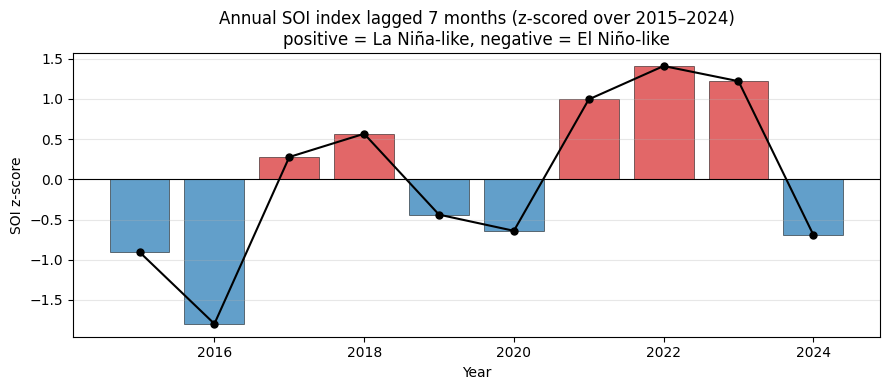

In [25]:
if HAS_SOI:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(years, soi_z, color=["#d62728" if z > 0 else "#1f77b4" for z in soi_z],
           alpha=0.7, edgecolor="k", linewidth=0.5)
    ax.plot(years, soi_z, "o-", color="k", linewidth=1.5, markersize=5)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_xlabel("Year")
    ax.set_ylabel("SOI z-score")
    ax.set_title(f"Annual SOI index lagged {SOI_LAG_MONTHS} months (z-scored over 2015–2024)\n"
                 "positive = La Niña-like, negative = El Niño-like")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "co_occ_nospo_annual_soi_lag7.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("SOI not available — skipping this figure.")


## 9. GOSIF predictor per component (Model B)

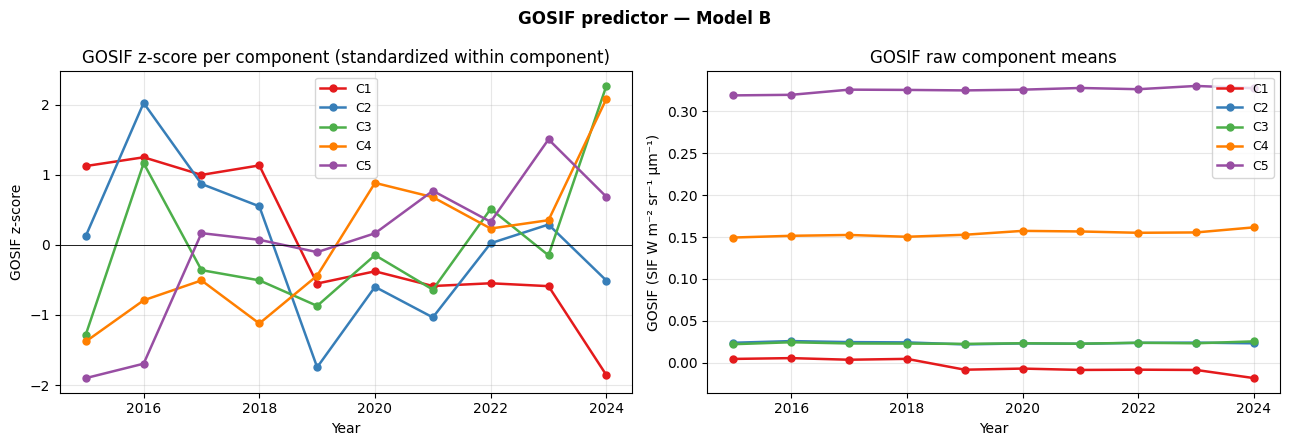

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for comp in COMPONENTS:
    ax.plot(years, gosif_z[comp], "o-", color=COMP_COLORS[comp],
            label=COMP_LABELS[comp], linewidth=1.8, markersize=5)
ax.axhline(0, color="k", linewidth=0.6)
ax.set_title("GOSIF z-score per component (standardized within component)")
ax.set_xlabel("Year"); ax.set_ylabel("GOSIF z-score")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
for comp in COMPONENTS:
    ax.plot(years, comp_means[comp]["gosif"], "o-", color=COMP_COLORS[comp],
            label=COMP_LABELS[comp], linewidth=1.8, markersize=5)
ax.set_title("GOSIF raw component means")
ax.set_xlabel("Year"); ax.set_ylabel("GOSIF (SIF W m⁻² sr⁻¹ μm⁻¹)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("GOSIF predictor — Model B", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "co_occ_nospo_gosif_predictor_per_component.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Component membership counts over time

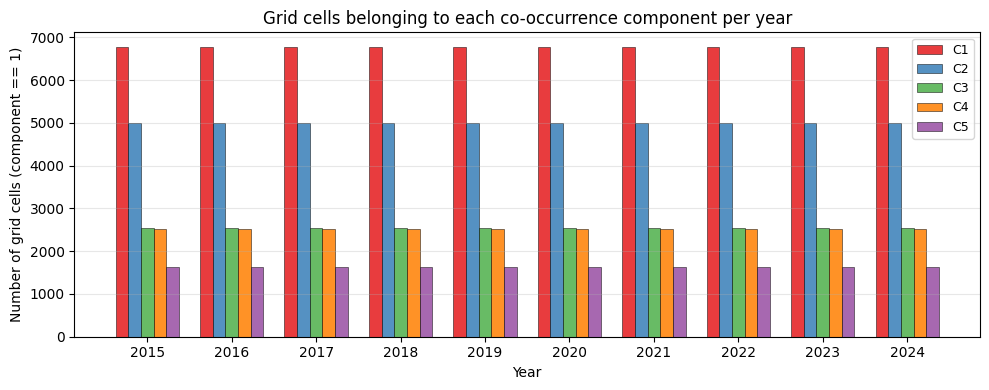

In [27]:
x   = np.arange(len(years))
w   = 0.15
fig, ax = plt.subplots(figsize=(10, 4))
for ci, comp in enumerate(COMPONENTS):
    ax.bar(x + ci * w, comp_ncells[comp], width=w,
           color=COMP_COLORS[comp], label=COMP_LABELS[comp],
           alpha=0.85, edgecolor="k", linewidth=0.4)
ax.set_xticks(x + 2 * w)
ax.set_xticklabels(years)
ax.set_xlabel("Year"); ax.set_ylabel("Number of grid cells (component == 1)")
ax.set_title("Grid cells belonging to each co-occurrence component per year")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "co_occ_nospo_membership_counts.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Spatial maps of co-occurrence components

Each panel shows the spatial footprint of one component: grid cells where `component_c == 1`
in **any** year are shown in the component colour, shaded by the **fraction of years**
they belong to it (light = occasional, saturated = always).

The final panel is a combined map: each cell is coloured by its **dominant component**
(highest fraction across years). Cells belonging to multiple components equally appear grey.

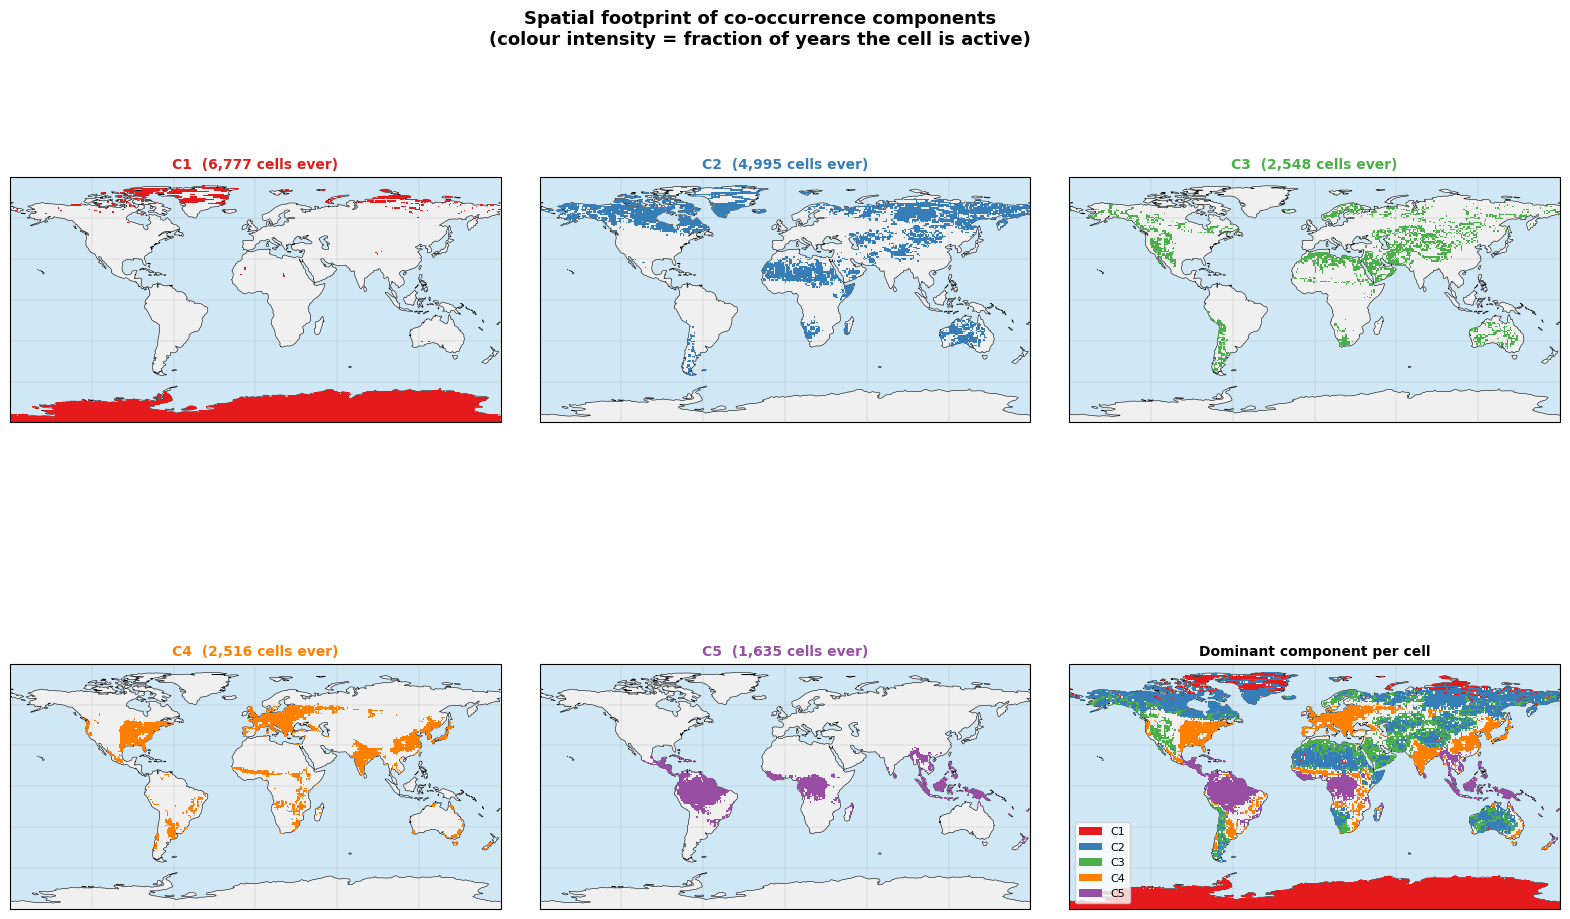

Saved → figures/co_occ_nospo_component_maps.png


In [28]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("cartopy not available — using plain pcolormesh")

import matplotlib.colors as mcolors

# ── Per-component fraction-of-years arrays ────────────────────────────────────
LON2D, LAT2D = np.meshgrid(lons, lats)   # (nlat, nlon)

comp_frac = {}   # fraction of years where component_c == 1
for comp in COMPONENTS:
    arr = (ds[comp] == 1.0).values.astype(float)        # (time, lat, lon), 0/1/nan
    with_data = np.isfinite(arr).sum(axis=0)
    frac = np.where(with_data > 0, np.nansum(arr, axis=0) / with_data, np.nan)
    comp_frac[comp] = frac   # (nlat, nlon)

# ── Dominant-component map ────────────────────────────────────────────────────
# For each cell: index of the component with the highest fraction (nan = none)
stack    = np.stack([comp_frac[c] for c in COMPONENTS], axis=0)   # (5, nlat, nlon)
any_mem  = np.nanmax(stack, axis=0) > 0                           # True if cell in any comp
dom_idx  = np.where(any_mem, np.nanargmax(stack, axis=0) + 1, np.nan).astype(float)
dom_idx  = np.where(any_mem, dom_idx, np.nan)

# ── Discrete colormap for combined map (5 comp colours + grey for multi-tie) ─
_c_list  = [COMP_COLORS[c] for c in COMPONENTS]
cmap_cat = mcolors.ListedColormap(_c_list)
bounds   = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm_cat = mcolors.BoundaryNorm(bounds, cmap_cat.N)

# ── Plot ──────────────────────────────────────────────────────────────────────
if HAS_CARTOPY:
    proj   = ccrs.PlateCarree()
    fig    = plt.figure(figsize=(20, 11))
    specs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.08)
    ax_idx = [(0,0),(0,1),(0,2),(1,0),(1,1)]   # 5 individual component panels
    ax_comb_spec = specs[1, 2]                 # combined map bottom-right

    axs_comp = [fig.add_subplot(specs[r, c], projection=proj) for r, c in ax_idx]
    ax_comb  = fig.add_subplot(ax_comb_spec, projection=proj)

    def _base(ax):
        ax.set_global()
        ax.add_feature(cfeature.LAND,  facecolor="#f0f0f0", zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor="#d0e8f5", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=1)
        ax.gridlines(draw_labels=False, linewidth=0.3, color="grey", alpha=0.4)

    for ci, comp in enumerate(COMPONENTS):
        ax  = axs_comp[ci]
        col = COMP_COLORS[comp]
        _base(ax)
        frac = comp_frac[comp]
        rgba = np.zeros((*frac.shape, 4))
        base = mcolors.to_rgba(col)
        mask = np.isfinite(frac) & (frac > 0)
        rgba[mask, 0] = base[0]; rgba[mask, 1] = base[1]; rgba[mask, 2] = base[2]
        rgba[mask, 3] = 0.25 + 0.75 * frac[mask]   # alpha encodes fraction
        ax.pcolormesh(LON2D, LAT2D, rgba, transform=proj, zorder=2)
        ax.set_title(f"{COMP_LABELS[comp]}  ({mask.sum():,} cells ever)",
                     fontsize=10, fontweight="bold", color=col)

    _base(ax_comb)
    ax_comb.pcolormesh(LON2D, LAT2D, dom_idx, transform=proj,
                       cmap=cmap_cat, norm=norm_cat, zorder=2)
    legend_patches = [Patch(facecolor=COMP_COLORS[c], label=COMP_LABELS[c])
                      for c in COMPONENTS]
    ax_comb.legend(handles=legend_patches, loc="lower left", fontsize=8, framealpha=0.8)
    ax_comb.set_title("Dominant component per cell", fontsize=10, fontweight="bold")

else:
    # ── Fallback: plain pcolormesh without cartopy ────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    land_color = "#f0f0f0"

    for ci, comp in enumerate(COMPONENTS):
        ax  = axes[ci // 3][ci % 3]
        col = COMP_COLORS[comp]
        frac = comp_frac[comp]
        rgba = np.zeros((*frac.shape, 4))
        base = mcolors.to_rgba(col)
        mask = np.isfinite(frac) & (frac > 0)
        rgba[mask, 0] = base[0]; rgba[mask, 1] = base[1]; rgba[mask, 2] = base[2]
        rgba[mask, 3] = 0.25 + 0.75 * frac[mask]
        bg = np.zeros((*frac.shape, 4))
        bg[:,:] = mcolors.to_rgba("#e8e8e8")
        bg[mask] = [0,0,0,0]
        ax.pcolormesh(LON2D, LAT2D, bg)
        ax.pcolormesh(LON2D, LAT2D, rgba)
        ax.set_title(f"{COMP_LABELS[comp]}  ({mask.sum():,} cells ever)",
                     fontsize=10, fontweight="bold", color=col)
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
        ax.grid(True, alpha=0.2)

    # Combined map
    ax = axes[1][2]
    ax.pcolormesh(LON2D, LAT2D, dom_idx, cmap=cmap_cat, norm=norm_cat)
    legend_patches = [Patch(facecolor=COMP_COLORS[c], label=COMP_LABELS[c])
                      for c in COMPONENTS]
    ax.legend(handles=legend_patches, loc="lower left", fontsize=8)
    ax.set_title("Dominant component per cell", fontsize=10, fontweight="bold")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.grid(True, alpha=0.2)

fig.suptitle("Spatial footprint of co-occurrence components\n"
             "(colour intensity = fraction of years the cell is active)",
             fontsize=13, fontweight="bold")
plt.savefig(FIGURE_DIR / "co_occ_nospo_component_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/co_occ_nospo_component_maps.png")


## 11. Observed vs predicted target per component

Analogous to §10 of `gridpoint_co2_regression_ols_emission_soi_lag7v2.ipynb`,
but repeated for all five components and both models.

- **Black** solid = observed (raw component mean)
- **Blue** dashed = Model A predicted (emission + SOI), full fit
- **Blue** dotted = Model A LOO
- **Green** dashed = Model B predicted (emission + GOSIF), full fit
- **Green** dotted = Model B LOO


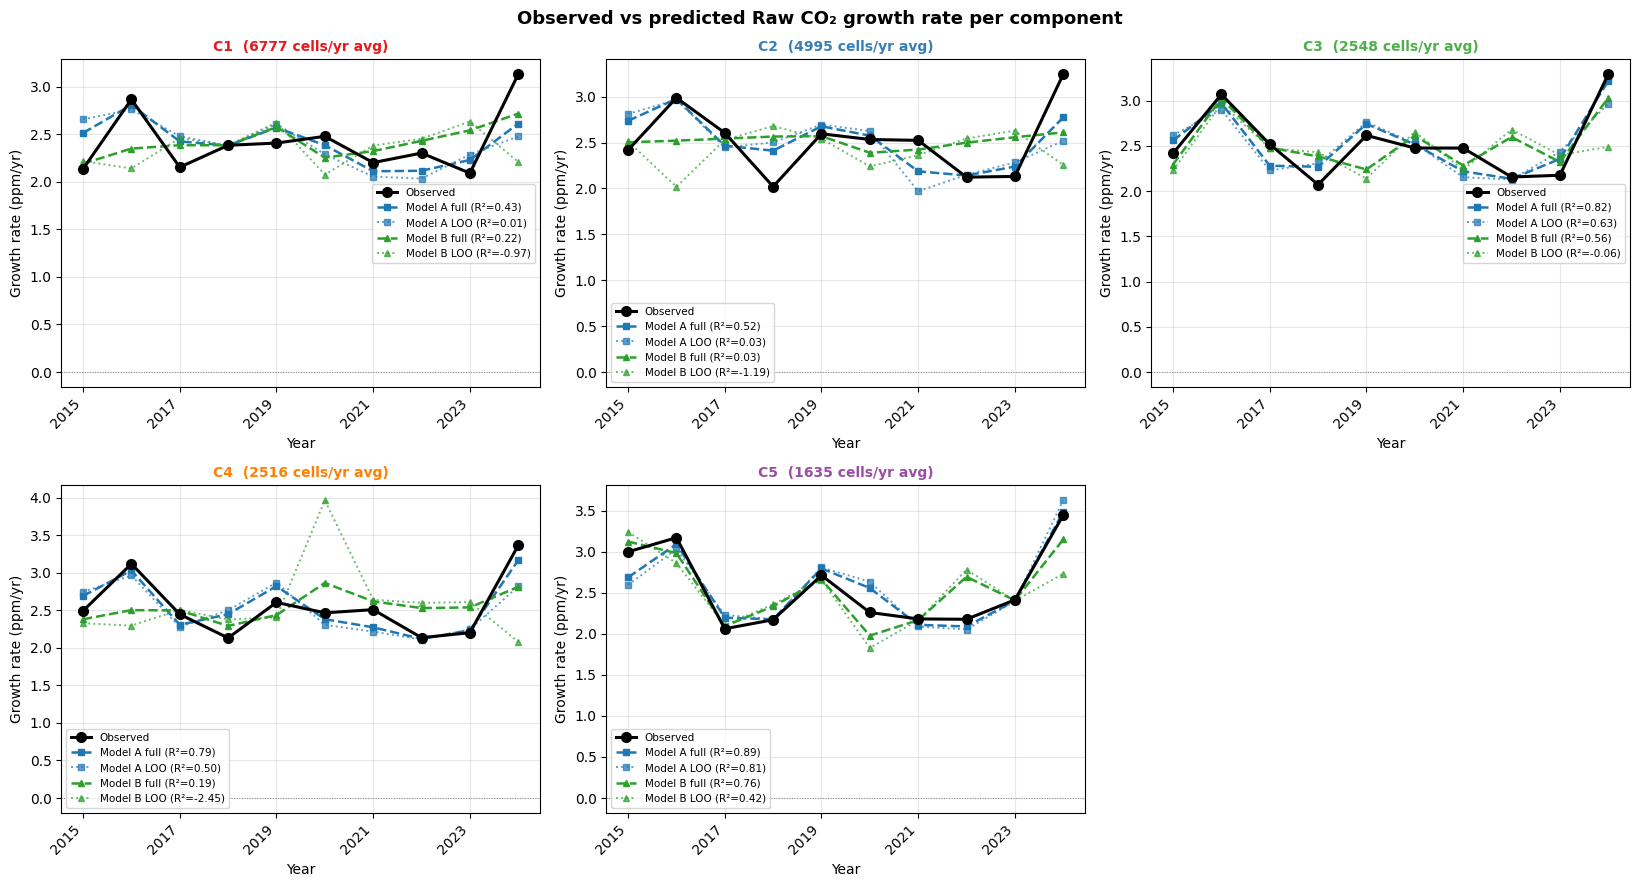

In [29]:
n_cl  = len(COMPONENTS)
ncols = min(n_cl, 3)
nrows = int(np.ceil(n_cl / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows), squeeze=False)

for ci, comp in enumerate(COMPONENTS):
    ax  = axes[ci // ncols][ci % ncols]
    col = COMP_COLORS[comp]
    lbl = COMP_LABELS[comp]
    obs = target[comp]

    ax.plot(years, obs, "o-", color="k", linewidth=2.2, markersize=7, zorder=5, label="Observed")

    if HAS_SOI and comp in preds_A_full:
        rA = results_A[comp]
        ax.plot(years, preds_A_full[comp], "s--", color="#1f77b4", linewidth=1.8,
                markersize=5, label=f"Model A full (R²={rA['r2']:.2f})")
        ax.plot(years, preds_A_loo[comp], "s:", color="#1f77b4", linewidth=1.4,
                markersize=4, alpha=0.7, label=f"Model A LOO (R²={rA['loo_r2']:.2f})")

    rB = results_B[comp]
    ax.plot(years, preds_B_full[comp], "^--", color="#2ca02c", linewidth=1.8,
            markersize=5, label=f"Model B full (R²={rB['r2']:.2f})")
    ax.plot(years, preds_B_loo[comp], "^:", color="#2ca02c", linewidth=1.4,
            markersize=4, alpha=0.7, label=f"Model B LOO (R²={rB['loo_r2']:.2f})")

    ax.axhline(0, color="grey", linewidth=0.7, linestyle=":")
    ax.set_xticks(range(years[0], years[-1]+1, 2))
    ax.set_xticklabels(range(years[0], years[-1]+1, 2), rotation=45, ha="right")
    ax.set_title(f"{lbl}  ({comp_ncells[comp].mean():.0f} cells/yr avg)", fontsize=10,
                 fontweight="bold", color=col)
    ax.set_ylabel("Growth rate (ppm/yr)"); ax.set_xlabel("Year")
    ax.legend(fontsize=7.5, loc="best"); ax.grid(True, alpha=0.3)

for ci in range(n_cl, nrows*ncols):
    axes[ci//ncols][ci%ncols].set_visible(False)

fig.suptitle("Observed vs predicted Raw CO₂ growth rate per component",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "co_occ_nospo_obs_vs_predicted_per_component.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Coefficient maps → bar charts

Analogous to the coefficient maps in §12 of the gridpoint notebook, adapted to
the component dimension.


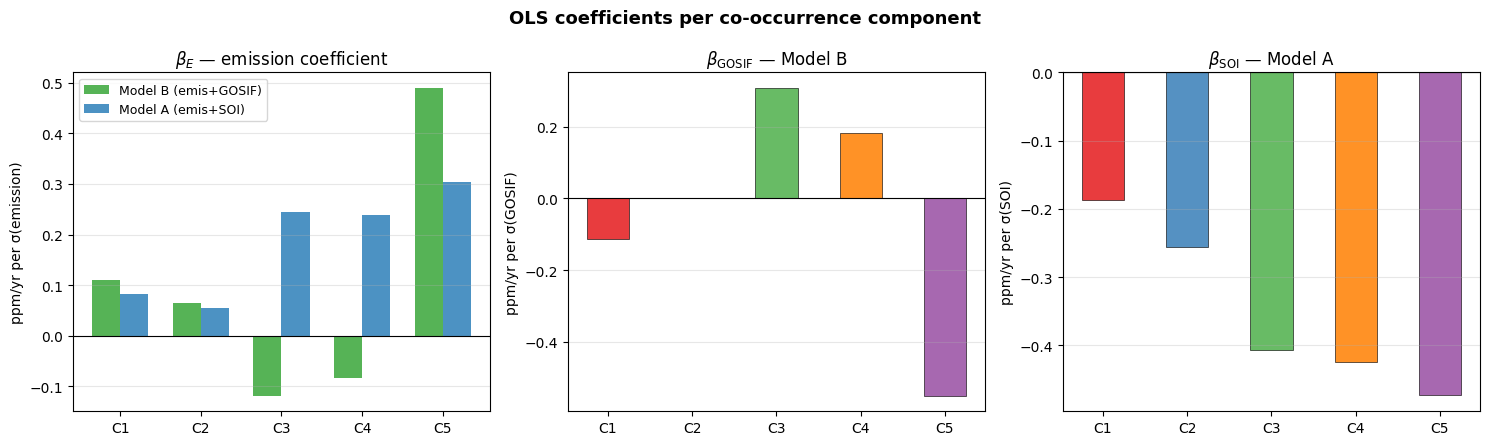

In [30]:
comp_lbls = [COMP_LABELS[c] for c in COMPONENTS]
x         = np.arange(len(COMPONENTS))
w         = 0.35

fig, axes = plt.subplots(1, 3 if HAS_SOI else 2,
                         figsize=(5*(3 if HAS_SOI else 2), 4.5))

# β_E (emission) — both models
ax = axes[0]
be_B = [results_B[c]["beta1"] for c in COMPONENTS]
ax.bar(x - w/2, be_B, width=w, color="#2ca02c", alpha=0.8, label="Model B (emis+GOSIF)")
if HAS_SOI:
    be_A = [results_A[c]["beta1"] for c in COMPONENTS]
    ax.bar(x + w/2, be_A, width=w, color="#1f77b4", alpha=0.8, label="Model A (emis+SOI)")
ax.set_xticks(x); ax.set_xticklabels(comp_lbls)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_title(r"$\beta_E$ — emission coefficient"); ax.set_ylabel("ppm/yr per σ(emission)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")

# β_GOSIF — Model B
ax = axes[1]
bg = [results_B[c]["beta2"] for c in COMPONENTS]
bars = ax.bar(x, bg, width=0.5,
              color=[COMP_COLORS[c] for c in COMPONENTS], alpha=0.85, edgecolor="k", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(comp_lbls)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_title(r"$\beta_{\text{GOSIF}}$ — Model B"); ax.set_ylabel("ppm/yr per σ(GOSIF)")
ax.grid(True, alpha=0.3, axis="y")

# β_SOI — Model A
if HAS_SOI:
    ax = axes[2]
    bs = [results_A[c]["beta2"] for c in COMPONENTS]
    ax.bar(x, bs, width=0.5,
           color=[COMP_COLORS[c] for c in COMPONENTS], alpha=0.85, edgecolor="k", linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(comp_lbls)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title(r"$\beta_{\text{SOI}}$ — Model A"); ax.set_ylabel("ppm/yr per σ(SOI)")
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("OLS coefficients per co-occurrence component", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "co_occ_nospo_coefficients_per_component.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Skill metrics

Analogous to the skill maps (§13) of the gridpoint notebook.  
`loo_rmse` and `loo_r2` are the honest out-of-sample metrics.


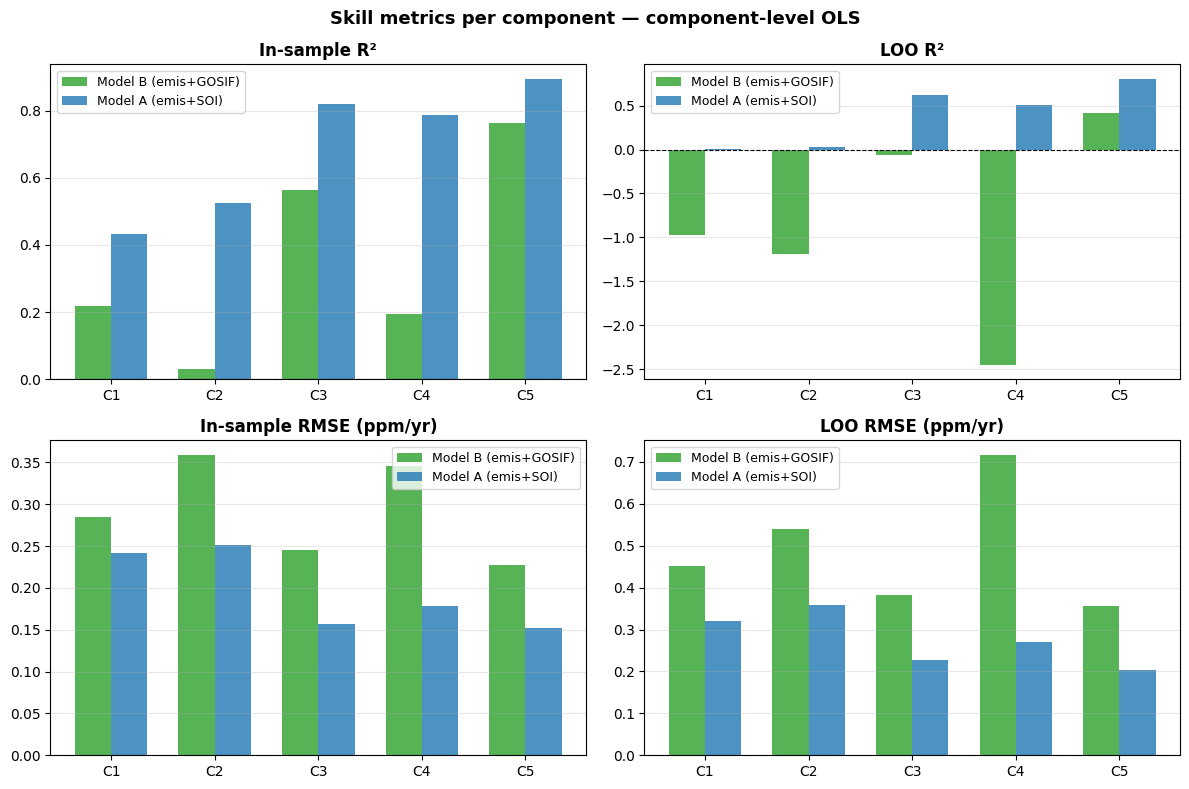

In [31]:
metrics = ["r2", "loo_r2", "rmse", "loo_rmse"]
titles  = ["In-sample R²", "LOO R²", "In-sample RMSE (ppm/yr)", "LOO RMSE (ppm/yr)"]
x       = np.arange(len(COMPONENTS))
w       = 0.35

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ai, (metric, title) in enumerate(zip(metrics, titles)):
    ax   = axes[ai]
    v_B  = [results_B[c][metric] for c in COMPONENTS]
    ax.bar(x - (w/2 if HAS_SOI else 0), v_B, width=w,
           color="#2ca02c", alpha=0.8, label="Model B (emis+GOSIF)")
    if HAS_SOI:
        v_A = [results_A[c][metric] for c in COMPONENTS]
        ax.bar(x + w/2, v_A, width=w,
               color="#1f77b4", alpha=0.8, label="Model A (emis+SOI)")
    ax.set_xticks(x); ax.set_xticklabels(comp_lbls)
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")
    if "r2" in metric:
        ax.axhline(0, color="k", linewidth=0.8, linestyle="--")

fig.suptitle("Skill metrics per component — component-level OLS", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "co_occ_nospo_skill_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Predictor contribution decomposition

Stacked bars showing how much each term (intercept, emission, 2nd predictor) contributes
to the predicted value each year.  Analogous to §16 city decomposition in the gridpoint notebook.


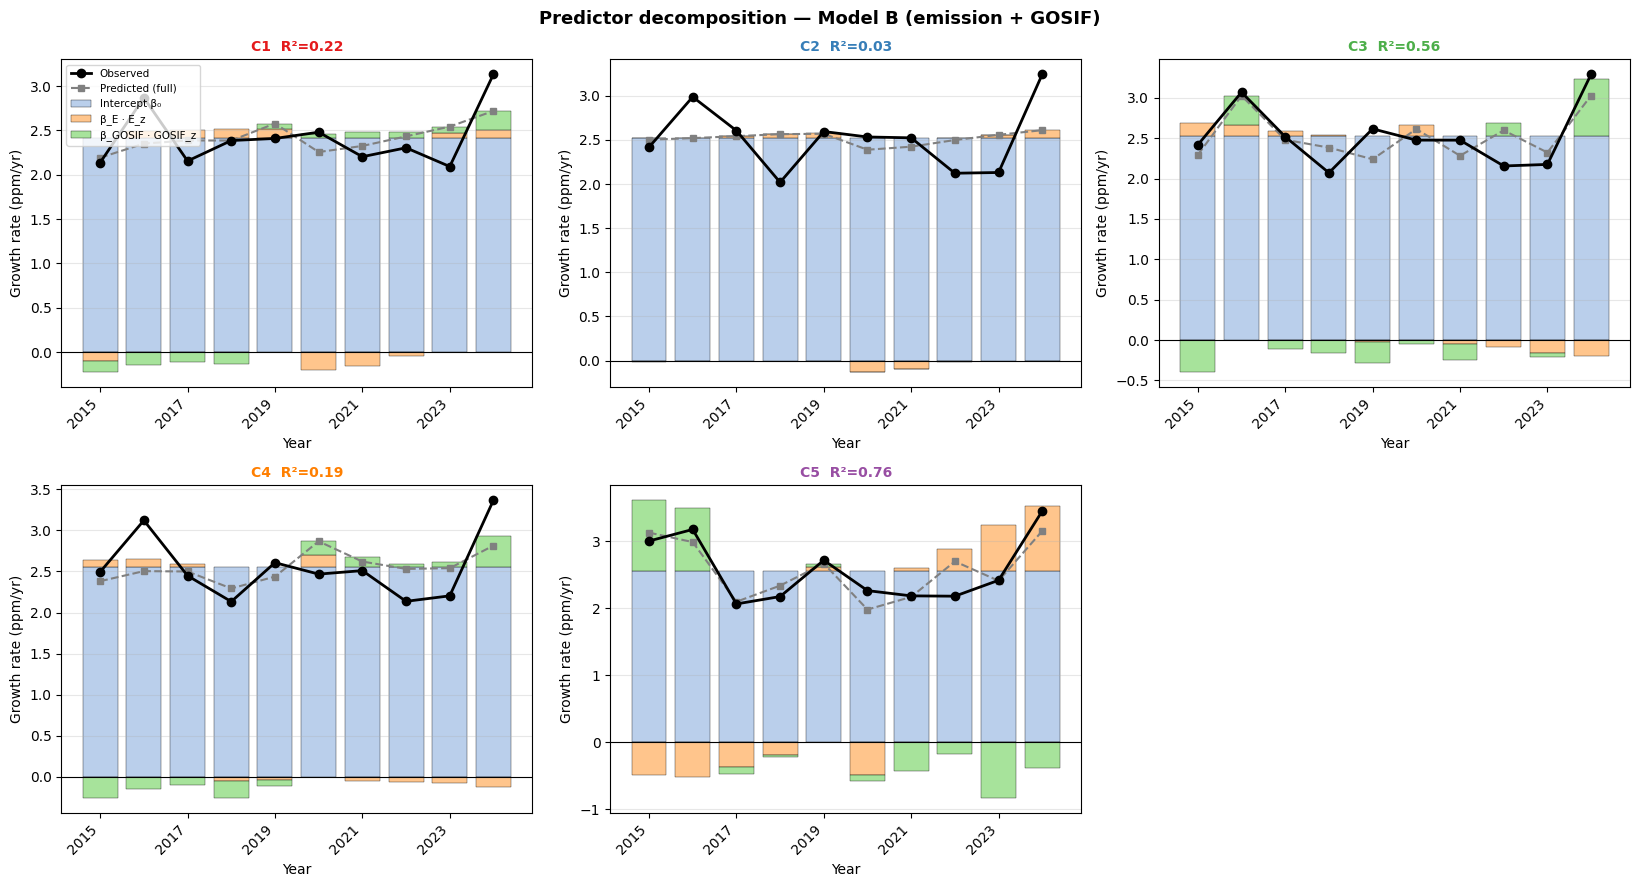

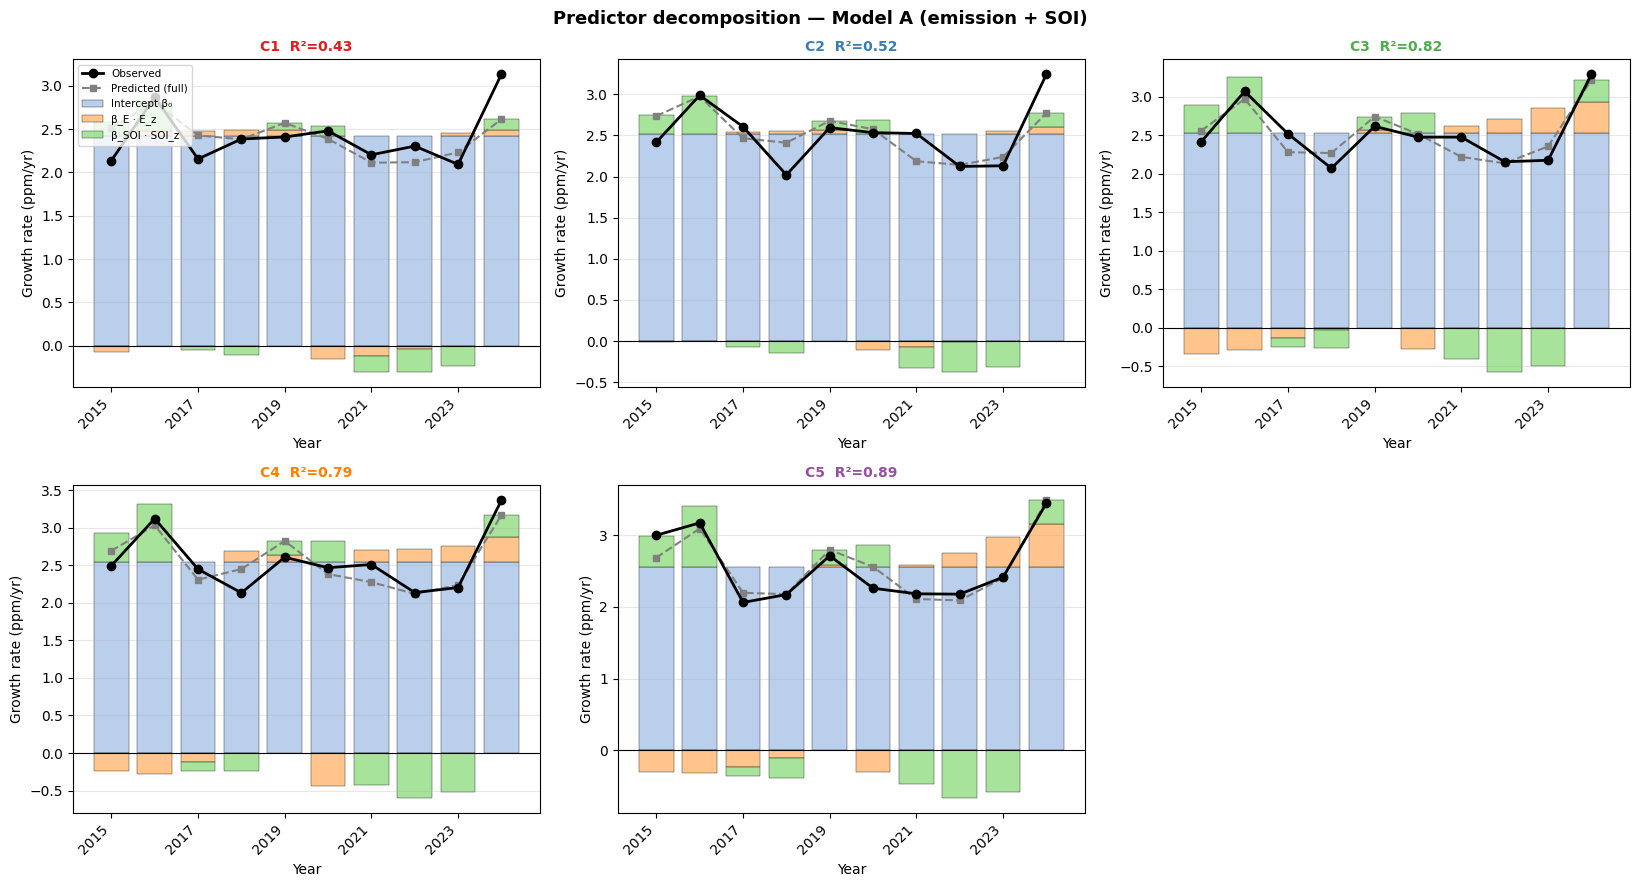

In [32]:
def decomp_plot(results, preds_full, x2_z_dict, x2_label, model_tag, save_name):
    n_cl  = len(COMPONENTS)
    ncols = min(n_cl, 3)
    nrows = int(np.ceil(n_cl / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows), squeeze=False)

    for ci, comp in enumerate(COMPONENTS):
        ax  = axes[ci//ncols][ci%ncols]
        col = COMP_COLORS[comp]
        r   = results[comp]
        if np.isnan(r["beta0"]):
            ax.text(0.5, 0.5, "not fitted", ha="center", va="center", transform=ax.transAxes)
            ax.set_visible(True); continue

        b0   = r["beta0"]
        b_e  = r["beta1"] * emission_z[comp]
        b_p2 = r["beta2"] * x2_z_dict[comp]

        bottom_pos = np.zeros(len(years))
        bottom_neg = np.zeros(len(years))
        parts = [
            ("Intercept β₀", np.full(len(years), b0), "#aec7e8"),
            (f"β_E · E_z",    b_e,                     "#ffbb78"),
            (f"{x2_label}",   b_p2,                    "#98df8a"),
        ]
        for part_label, vals, part_col in parts:
            pos_mask = vals >= 0
            ax.bar(years[pos_mask],  vals[pos_mask],  bottom=bottom_pos[pos_mask],
                   color=part_col, alpha=0.85, label=part_label, edgecolor="k", linewidth=0.3)
            ax.bar(years[~pos_mask], vals[~pos_mask], bottom=bottom_neg[~pos_mask],
                   color=part_col, alpha=0.85, edgecolor="k", linewidth=0.3)
            bottom_pos[pos_mask]  += vals[pos_mask]
            bottom_neg[~pos_mask] += vals[~pos_mask]

        ax.plot(years, target[comp], "o-", color="k", linewidth=2, markersize=6,
                zorder=5, label="Observed")
        ax.plot(years, preds_full[comp], "s--", color="grey", linewidth=1.5,
                markersize=4, label="Predicted (full)")
        ax.axhline(0, color="k", linewidth=0.8)
        ax.set_xticks(range(years[0], years[-1]+1, 2))
        ax.set_xticklabels(range(years[0], years[-1]+1, 2), rotation=45, ha="right")
        ax.set_title(f"{COMP_LABELS[comp]}  R²={r['r2']:.2f}", fontsize=10,
                     fontweight="bold", color=col)
        ax.set_ylabel("Growth rate (ppm/yr)"); ax.set_xlabel("Year")
        if ci == 0:
            ax.legend(fontsize=7.5, loc="upper left")
        ax.grid(True, alpha=0.3, axis="y")

    for ci in range(n_cl, nrows*ncols):
        axes[ci//ncols][ci%ncols].set_visible(False)
    fig.suptitle(f"Predictor decomposition — {model_tag}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()

decomp_plot(results_B, preds_B_full,
            gosif_z, "β_GOSIF · GOSIF_z",
            "Model B (emission + GOSIF)",
            "co_occ_nospo_decomp_model_B.png")

if HAS_SOI:
    soi_z_dict = {comp: soi_z for comp in COMPONENTS}
    decomp_plot(results_A, preds_A_full,
                soi_z_dict, "β_SOI · SOI_z",
                "Model A (emission + SOI)",
                "co_occ_nospo_decomp_model_A.png")


## 15. Model A vs Model B comparison

Analogous to the level-vs-delta emission comparison in §14 of the gridpoint notebook.


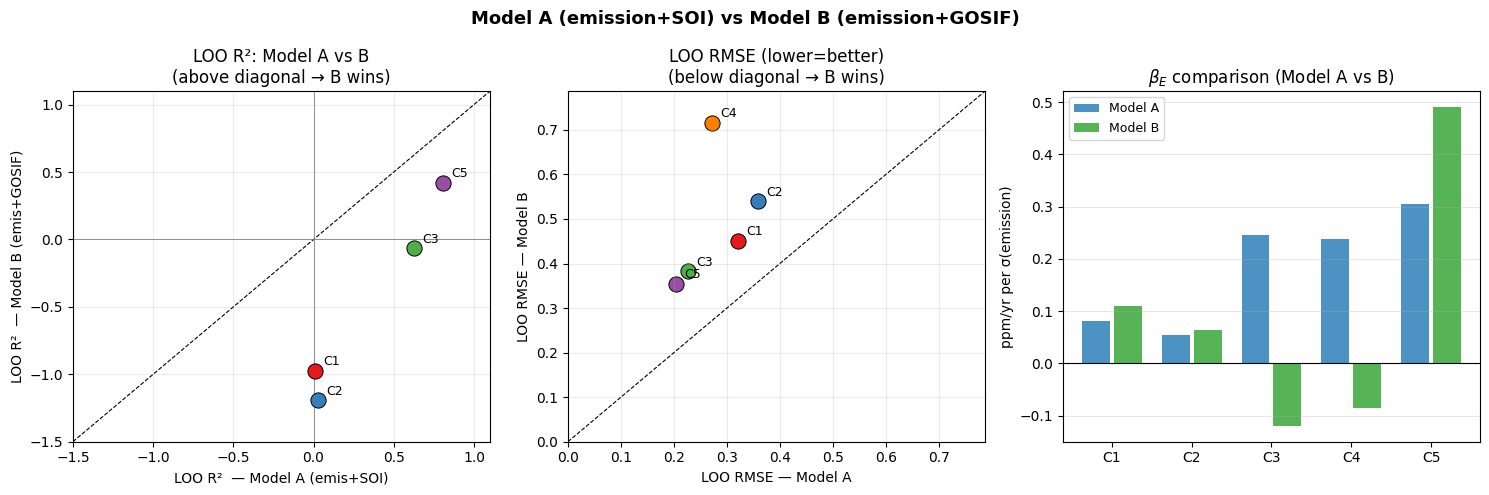

In [34]:
if HAS_SOI:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # LOO R² scatter
    ax = axes[0]
    r2_A = [results_A[c]["loo_r2"] for c in COMPONENTS]
    r2_B = [results_B[c]["loo_r2"] for c in COMPONENTS]
    for ci, comp in enumerate(COMPONENTS):
        ax.scatter(r2_A[ci], r2_B[ci], s=120, color=COMP_COLORS[comp],
                   zorder=5, label=COMP_LABELS[comp], edgecolors="k", linewidths=0.7)
        ax.annotate(COMP_LABELS[comp], (r2_A[ci], r2_B[ci]),
                    textcoords="offset points", xytext=(6,4), fontsize=9)
    lims = [-1.5, 1.1]
    ax.plot(lims, lims, "k--", lw=0.8)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("LOO R²  — Model A (emis+SOI)")
    ax.set_ylabel("LOO R²  — Model B (emis+GOSIF)")
    ax.set_title("LOO R²: Model A vs B\n(above diagonal → B wins)")
    ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
    ax.grid(True, alpha=0.25)

    # LOO RMSE scatter
    ax = axes[1]
    rm_A = [results_A[c]["loo_rmse"] for c in COMPONENTS]
    rm_B = [results_B[c]["loo_rmse"] for c in COMPONENTS]
    for ci, comp in enumerate(COMPONENTS):
        ax.scatter(rm_A[ci], rm_B[ci], s=120, color=COMP_COLORS[comp],
                   edgecolors="k", linewidths=0.7)
        ax.annotate(COMP_LABELS[comp], (rm_A[ci], rm_B[ci]),
                    textcoords="offset points", xytext=(6,4), fontsize=9)
    lim_r = [0, max(max(rm_A), max(rm_B))*1.1]
    ax.plot(lim_r, lim_r, "k--", lw=0.8)
    ax.set_xlim(lim_r); ax.set_ylim(lim_r)
    ax.set_xlabel("LOO RMSE — Model A")
    ax.set_ylabel("LOO RMSE — Model B")
    ax.set_title("LOO RMSE (lower=better)\n(below diagonal → B wins)")
    ax.grid(True, alpha=0.25)

    # β_E comparison
    ax = axes[2]
    be_A = [results_A[c]["beta1"] for c in COMPONENTS]
    be_B = [results_B[c]["beta1"] for c in COMPONENTS]
    xp   = np.arange(len(COMPONENTS))
    ax.bar(xp - 0.2, be_A, width=0.35, color="#1f77b4", alpha=0.8, label="Model A")
    ax.bar(xp + 0.2, be_B, width=0.35, color="#2ca02c", alpha=0.8, label="Model B")
    ax.set_xticks(xp); ax.set_xticklabels(comp_lbls)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(r"$\beta_E$ comparison (Model A vs B)")
    ax.set_ylabel("ppm/yr per σ(emission)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")

    fig.suptitle("Model A (emission+SOI) vs Model B (emission+GOSIF)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "co_occ_nospo_model_A_vs_B.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("SOI not available — skipping Model A vs B comparison.")


## 16. Comparison with per-grid-cell results

Compares the component-level coefficients from **Model B** (emission + GOSIF) with
the distribution of per-cell coefficients from the existing gridpoint regression
(`outputs/gridpoint_regression_standardized_anomalies_fill0.nc`).

For each component, we extract all grid cells that ever belong to it and show a
violin/box of their per-cell `beta_E` and `beta_B` — overlaid with the
component-level β from this notebook.

> **Caveat:** the gridpoint notebook uses standardised anomalies as the target
> (global-mean-removed, then z-scored), while this notebook uses the SPO-referenced
> raw growth rate.  Coefficient magnitudes are therefore not directly comparable, but
> the pattern across components should be informative.


Gridpoint regression NC loaded:
<xarray.Dataset> Size: 42MB
Dimensions:                         (lat: 180, lon: 360, time: 10)
Coordinates:
  * lat                             (lat) float64 1kB -89.5 -88.5 ... 88.5 89.5
  * lon                             (lon) float64 3kB -179.5 -178.5 ... 179.5
  * time                            (time) int64 80B 2015 2016 ... 2023 2024
Data variables: (12/26)
    beta0                           (lat, lon) float64 518kB ...
    beta_E                          (lat, lon) float64 518kB ...
    beta_B                          (lat, lon) float64 518kB ...
    r2                              (lat, lon) float64 518kB ...
    rmse                            (lat, lon) float64 518kB ...
    n_obs                           (lat, lon) int16 130kB ...
    ...                              ...
    growth_rate_temporal_std        (lat, lon) float64 518kB ...
    emission_temporal_std           (lat, lon) float32 259kB ...
    gosif_temporal_std              (lat, 

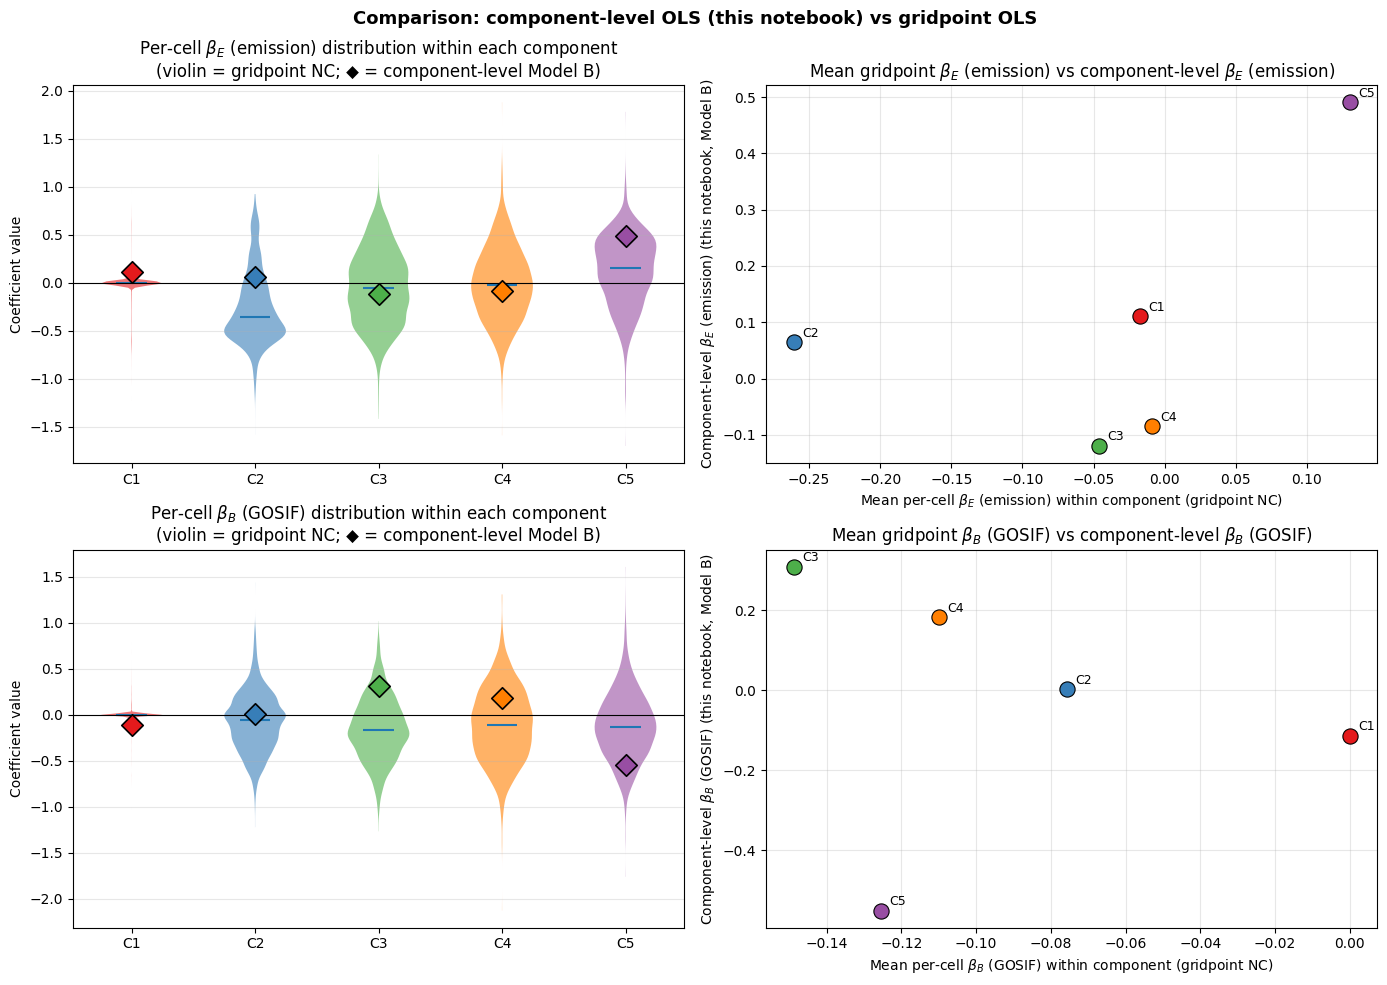

In [35]:
GP_NC = Path("outputs/gridpoint_regression_standardized_anomalies_fill0.nc")

if GP_NC.exists():
    ds_gp = xr.open_dataset(GP_NC)
    print("Gridpoint regression NC loaded:")
    print(ds_gp)

    # Build modal (most-common across years) component mask per grid cell
    modal_comp = {}
    for comp in COMPONENTS:
        # True if this cell belongs to the component in any year
        modal_comp[comp] = (ds[comp] == 1.0).any("time").values   # (lat, lon)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    gp_vars  = ["beta_E", "beta_B"]
    gp_title = [r"$\beta_E$ (emission)", r"$\beta_B$ (GOSIF)"]
    nb_keys  = ["beta1", "beta2"]

    for row, (gp_var, gp_t, nb_key) in enumerate(zip(gp_vars, gp_title, nb_keys)):
        gp_flat = ds_gp[gp_var].values   # (lat, lon)

        # Violin per component
        ax = axes[row][0]
        data_per_comp = []
        for comp in COMPONENTS:
            mask = modal_comp[comp] & np.isfinite(gp_flat)
            vals = gp_flat[mask].ravel()
            data_per_comp.append(vals)

        parts = ax.violinplot(data_per_comp, positions=range(len(COMPONENTS)),
                              showmedians=True, showextrema=False)
        for bi, body in enumerate(parts["bodies"]):
            body.set_facecolor(COMP_COLORS[COMPONENTS[bi]])
            body.set_alpha(0.6)

        # Overlay component-level β from Model B
        for ci, comp in enumerate(COMPONENTS):
            nb_val = results_B[comp][nb_key]
            if not np.isnan(nb_val):
                ax.scatter(ci, nb_val, s=120, color=COMP_COLORS[comp],
                           zorder=6, edgecolors="k", linewidths=1.2,
                           marker="D", label=f"{COMP_LABELS[comp]} comp-level")

        ax.set_xticks(range(len(COMPONENTS)))
        ax.set_xticklabels(comp_lbls)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_title(f"Per-cell {gp_t} distribution within each component\n"
                     f"(violin = gridpoint NC; ◆ = component-level Model B)")
        ax.set_ylabel("Coefficient value")
        ax.grid(True, alpha=0.3, axis="y")

        # Scatter: per-cell vs component-level β
        ax = axes[row][1]
        for ci, comp in enumerate(COMPONENTS):
            mask = modal_comp[comp] & np.isfinite(gp_flat)
            cell_vals = gp_flat[mask].ravel()
            cell_mean = np.nanmean(cell_vals)
            nb_val    = results_B[comp][nb_key]
            ax.scatter(cell_mean, nb_val, s=120, color=COMP_COLORS[comp],
                       edgecolors="k", linewidths=0.8, zorder=5,
                       label=COMP_LABELS[comp])
            ax.annotate(COMP_LABELS[comp], (cell_mean, nb_val),
                        textcoords="offset points", xytext=(6, 4), fontsize=9)

        ax.set_xlabel(f"Mean per-cell {gp_t} within component (gridpoint NC)")
        ax.set_ylabel(f"Component-level {gp_t} (this notebook, Model B)")
        ax.set_title(f"Mean gridpoint {gp_t} vs component-level {gp_t}")
        _all = [results_B[c][nb_key] for c in COMPONENTS
                if not np.isnan(results_B[c][nb_key])]
        ax.grid(True, alpha=0.3)

    fig.suptitle("Comparison: component-level OLS (this notebook) vs gridpoint OLS",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "co_occ_nospo_vs_gridpoint_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Gridpoint NC not found at {GP_NC}.")
    print("Run gridpoint_co2_regression_ols_emission_soi_lag7v2.ipynb first to generate it.")


## 18. Spatial prediction maps — Model A (emission+SOI) and Model B (emission+GOSIF)

Each grid cell is coloured by its **dominant component's predicted growth rate** for that year.
The dominant component is the one to which a cell belongs in the highest fraction of years.

Three figures are produced:

1. **Time-mean maps** — observed, Model A, and Model B, averaged across all years.
2. **Year-by-year Model A** — 10 panels (one per year) showing the annual spatial prediction.
3. **Year-by-year Model B** — same layout for Model B.

A consistent colour scale (based on the observed range) is shared across all year-by-year panels.


/var/folders/mq/8cqtklp970s7fwwrslgzkww80000gn/T/ipykernel_93815/214646514.py:76: RuntimeWarning: Mean of empty slice
  _pcolormesh_map(axes[0], np.nanmean(obs_map, axis=0),
/var/folders/mq/8cqtklp970s7fwwrslgzkww80000gn/T/ipykernel_93815/214646514.py:80: RuntimeWarning: Mean of empty slice
  _pcolormesh_map(axes[1], np.nanmean(pred_map_A, axis=0),
/var/folders/mq/8cqtklp970s7fwwrslgzkww80000gn/T/ipykernel_93815/214646514.py:83: RuntimeWarning: Mean of empty slice
  _pcolormesh_map(axes[2], np.nanmean(pred_map_B, axis=0),


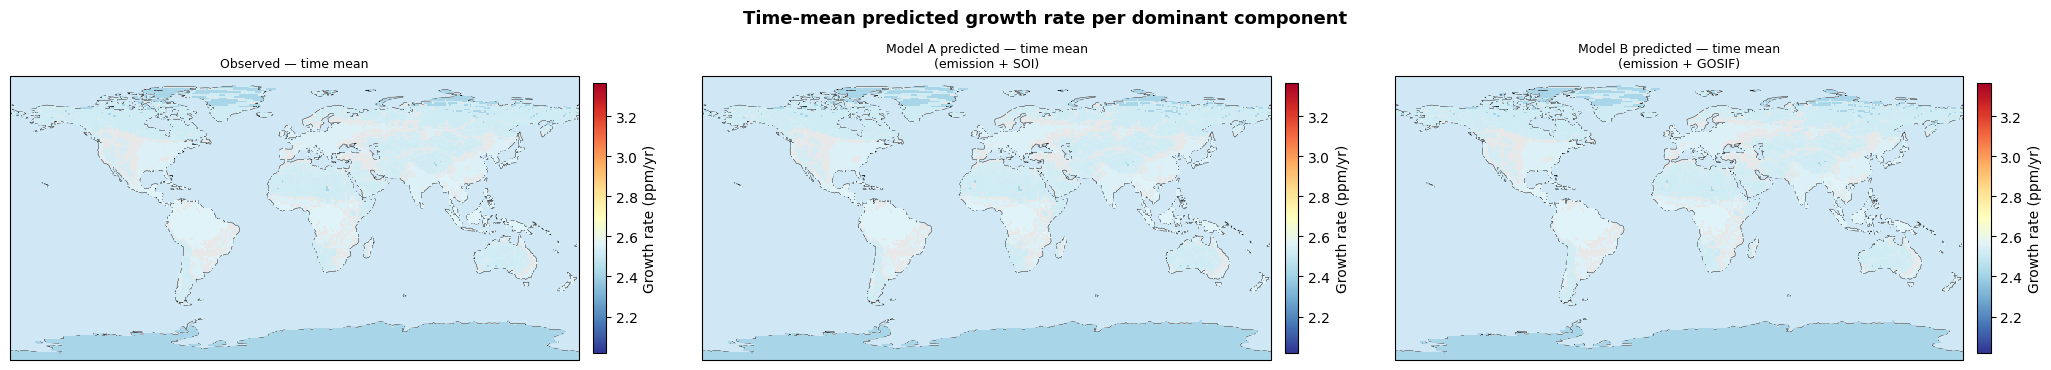

Saved → figures/co_occ_nospo_pred_maps_timemean.png


/var/folders/mq/8cqtklp970s7fwwrslgzkww80000gn/T/ipykernel_93815/214646514.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


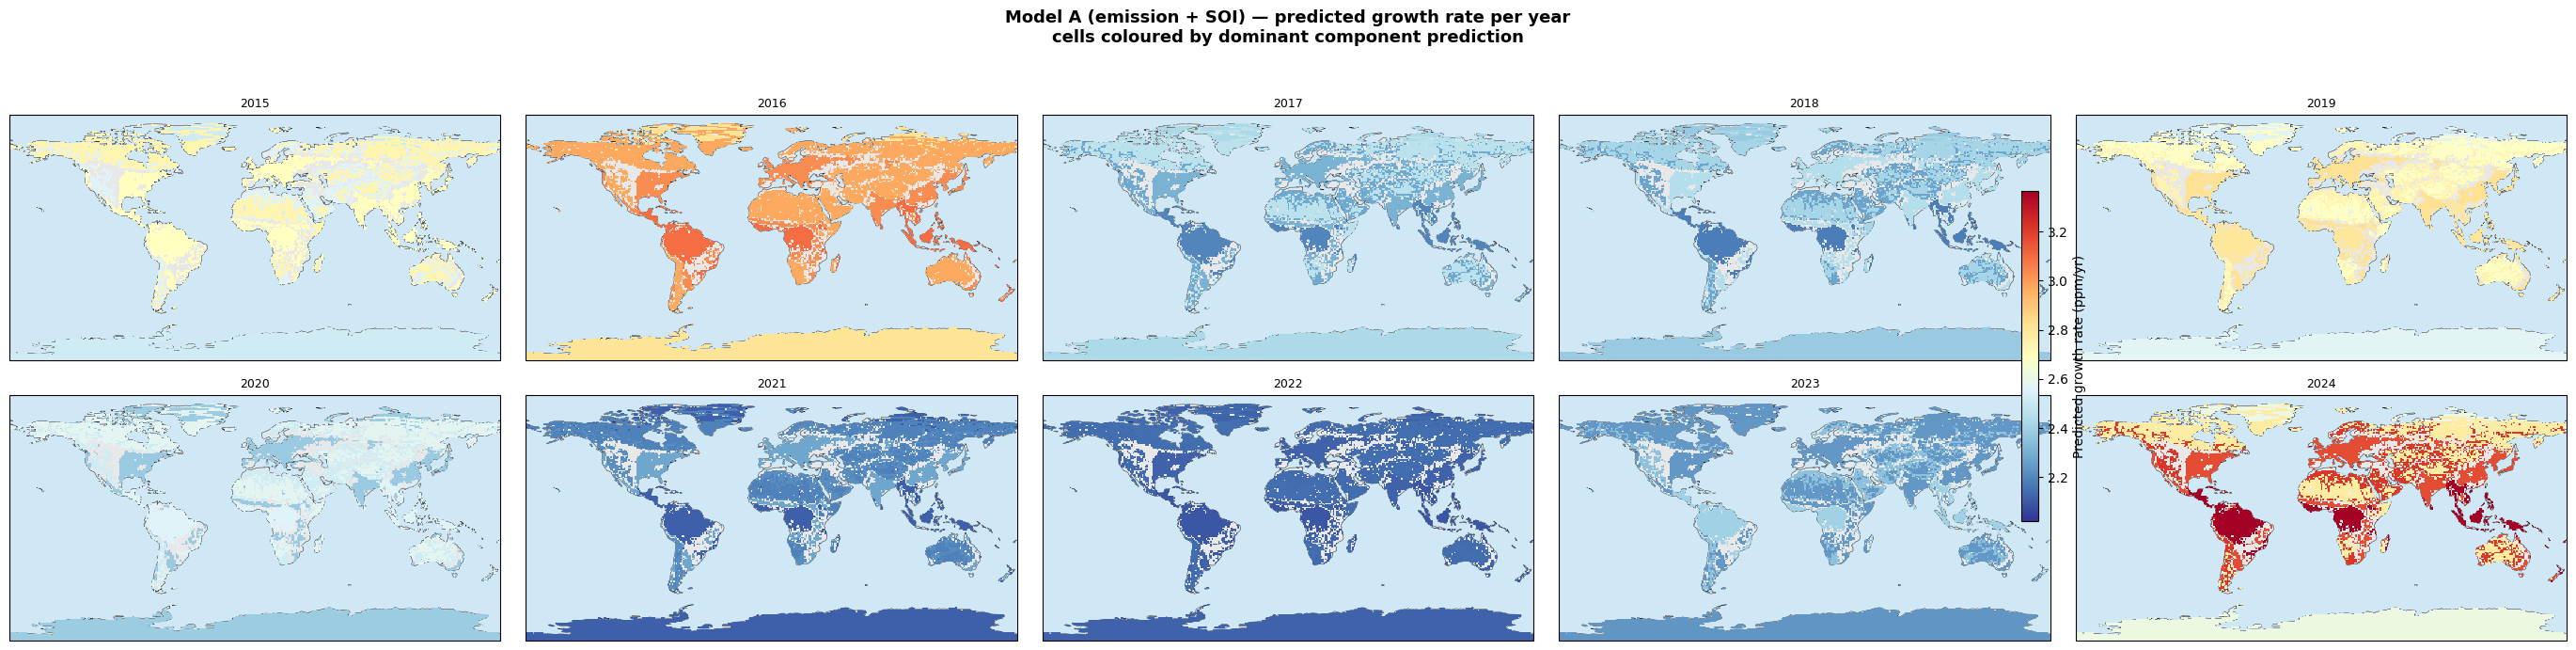

Saved → figures/co_occ_nospo_pred_maps_A_yearly.png


/var/folders/mq/8cqtklp970s7fwwrslgzkww80000gn/T/ipykernel_93815/214646514.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


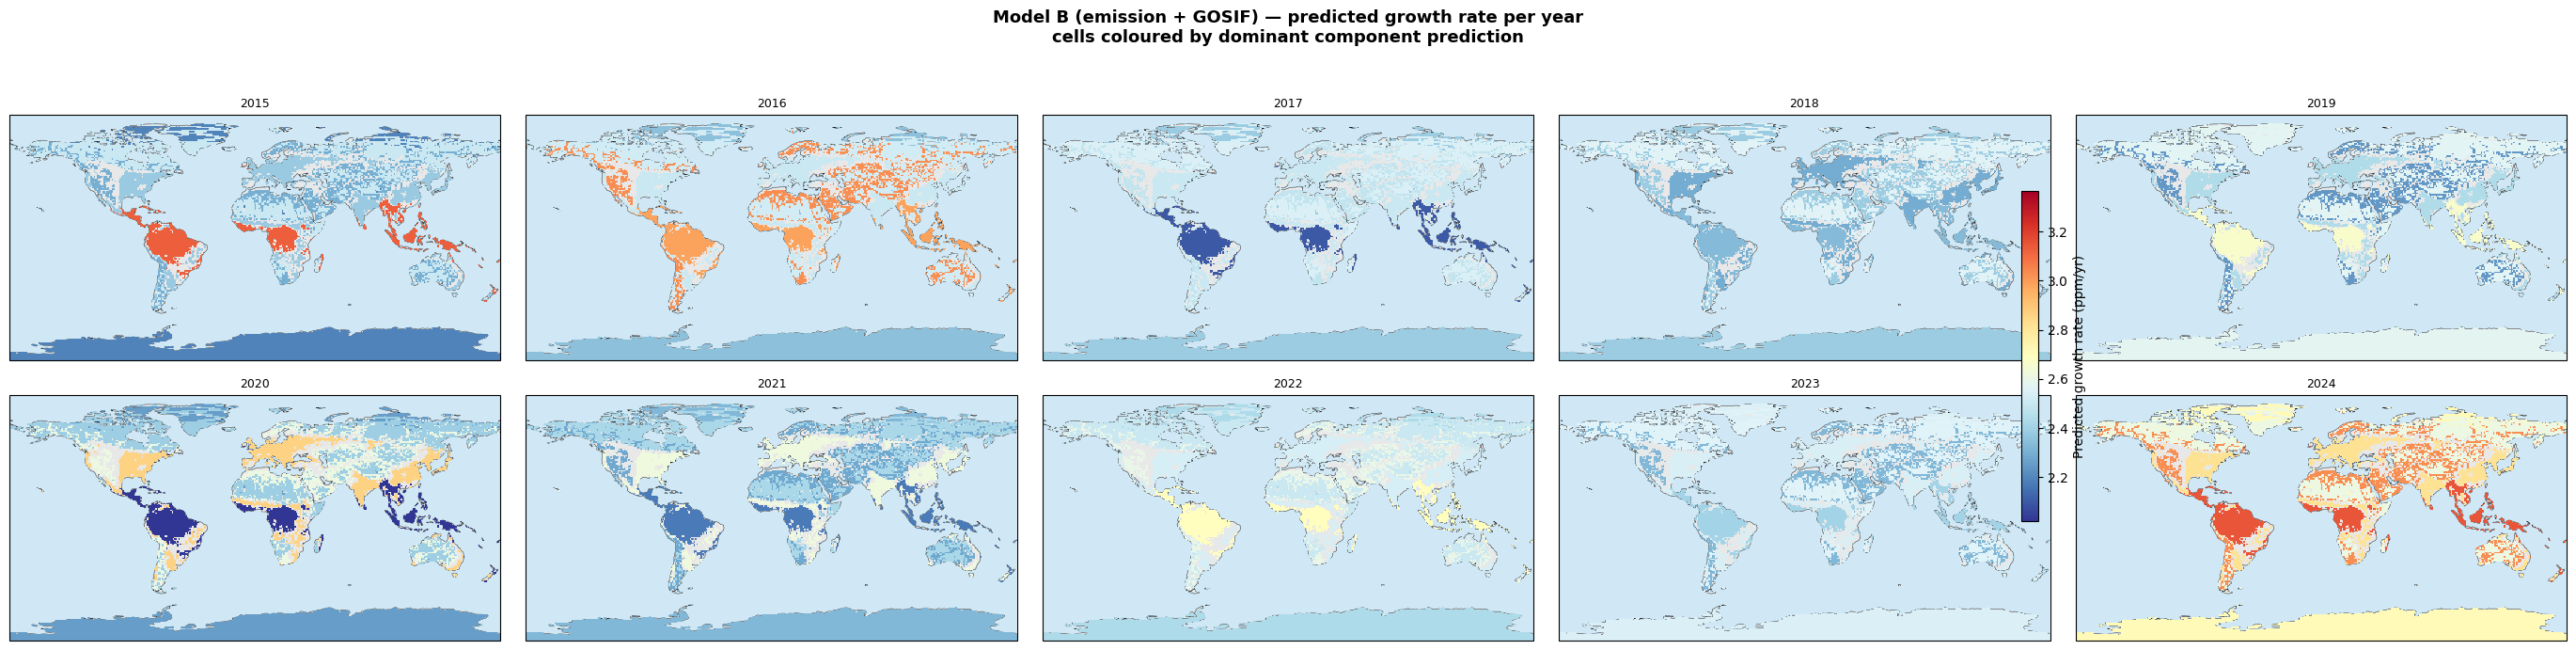

Saved → figures/co_occ_nospo_pred_maps_B_yearly.png


/var/folders/mq/8cqtklp970s7fwwrslgzkww80000gn/T/ipykernel_93815/214646514.py:177: RuntimeWarning: Mean of empty slice
  resid_A = np.nanmean(obs_map - pred_map_A, axis=0)
/var/folders/mq/8cqtklp970s7fwwrslgzkww80000gn/T/ipykernel_93815/214646514.py:181: RuntimeWarning: Mean of empty slice
  resid_B = np.nanmean(obs_map - pred_map_B, axis=0)


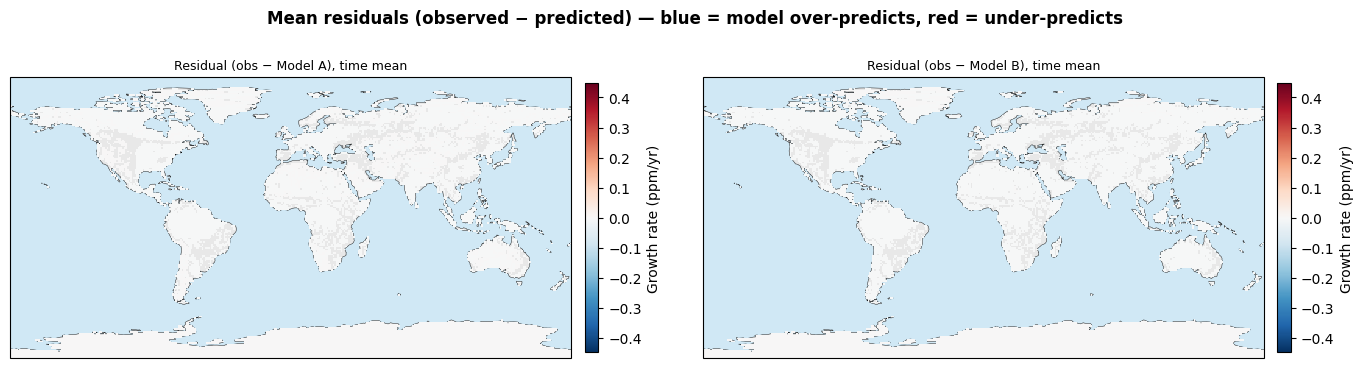

Saved → figures/co_occ_nospo_pred_maps_residuals.png


In [36]:
import matplotlib.colors as mcolors

# ── Recompute comp_frac and grids if cell 23 was skipped ─────────────────────
try:
    _ = comp_frac
    _ = LON2D
except NameError:
    LON2D, LAT2D = np.meshgrid(lons, lats)
    comp_frac = {}
    for comp in COMPONENTS:
        arr = (ds[comp] == 1.0).values.astype(float)
        n_valid = np.isfinite(arr).sum(axis=0)
        comp_frac[comp] = np.where(n_valid > 0, np.nansum(arr, axis=0) / n_valid, np.nan)

# ── Dominant component index per cell (0–4, or -1 for no component) ──────────
stack   = np.stack([comp_frac[c] for c in COMPONENTS], axis=0)   # (5, nlat, nlon)
any_mem = np.nanmax(stack, axis=0) > 0
dom_idx = np.where(any_mem, np.nanargmax(stack, axis=0), -1)      # int (nlat, nlon)

# ── Build spatial maps: (n_years, nlat, nlon) for obs, pred_A, pred_B ────────
n_yr = len(years)
obs_map    = np.full((n_yr, len(lats), len(lons)), np.nan)
pred_map_A = np.full((n_yr, len(lats), len(lons)), np.nan)
pred_map_B = np.full((n_yr, len(lats), len(lons)), np.nan)

for ci, comp in enumerate(COMPONENTS):
    cell_mask = (dom_idx == ci)   # (nlat, nlon)
    for yi in range(n_yr):
        obs_map[yi, cell_mask]    = target[comp][yi]
        pred_map_B[yi, cell_mask] = preds_B_full[comp][yi]
        if HAS_SOI and comp in preds_A_full:
            pred_map_A[yi, cell_mask] = preds_A_full[comp][yi]

# ── Shared colour scale (based on observed data range across all years) ───────
all_vals = obs_map[np.isfinite(obs_map)]
vmin_obs = float(np.percentile(all_vals, 2))
vmax_obs = float(np.percentile(all_vals, 98))
cmap     = "RdYlBu_r"

def _pcolormesh_map(ax, data, title, vmin, vmax, cmap, show_cbar=True):
    """Single-panel pcolormesh map with optional coastlines."""
    if HAS_CARTOPY:
        import cartopy.feature as cfeature
        import cartopy.crs   as ccrs
        ax.set_global()
        ax.add_feature(cfeature.LAND,      facecolor="#e8e8e8", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="#d0e8f5", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3,       zorder=1)
        transform = ccrs.PlateCarree()
        im = ax.pcolormesh(LON2D, LAT2D, data, transform=transform,
                           cmap=cmap, vmin=vmin, vmax=vmax, zorder=2)
    else:
        ax.set_facecolor("#d0e8f5")
        im = ax.pcolormesh(LON2D, LAT2D, data, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
        ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    ax.set_title(title, fontsize=9)
    if show_cbar:
        plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02,
                     label="Growth rate (ppm/yr)", shrink=0.8)
    return im

# ════════════════════════════════════════════════════════════════════════════════
# Figure 1 — Time-mean maps (obs | Model A | Model B)
# ════════════════════════════════════════════════════════════════════════════════
n_panels = 3 if HAS_SOI else 2
if HAS_CARTOPY:
    import cartopy.crs as ccrs
    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(1, n_panels, figsize=(7*n_panels, 4),
                             subplot_kw={"projection": proj})
else:
    fig, axes = plt.subplots(1, n_panels, figsize=(7*n_panels, 3.5))
axes = np.atleast_1d(axes)

_pcolormesh_map(axes[0], np.nanmean(obs_map, axis=0),
                "Observed — time mean", vmin_obs, vmax_obs, cmap)

if HAS_SOI:
    _pcolormesh_map(axes[1], np.nanmean(pred_map_A, axis=0),
                    "Model A predicted — time mean\n(emission + SOI)",
                    vmin_obs, vmax_obs, cmap)
    _pcolormesh_map(axes[2], np.nanmean(pred_map_B, axis=0),
                    "Model B predicted — time mean\n(emission + GOSIF)",
                    vmin_obs, vmax_obs, cmap)
else:
    _pcolormesh_map(axes[1], np.nanmean(pred_map_B, axis=0),
                    "Model B predicted — time mean\n(emission + GOSIF)",
                    vmin_obs, vmax_obs, cmap)

fig.suptitle("Time-mean predicted growth rate per dominant component",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "co_occ_nospo_pred_maps_timemean.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/co_occ_nospo_pred_maps_timemean.png")

# ════════════════════════════════════════════════════════════════════════════════
# Figure 2 — Year-by-year Model A
# ════════════════════════════════════════════════════════════════════════════════
if HAS_SOI:
    ncols_y = 5
    nrows_y = int(np.ceil(n_yr / ncols_y))
    if HAS_CARTOPY:
        fig2, axes2 = plt.subplots(nrows_y, ncols_y,
                                   figsize=(5.5*ncols_y, 3.8*nrows_y),
                                   subplot_kw={"projection": proj})
    else:
        fig2, axes2 = plt.subplots(nrows_y, ncols_y,
                                   figsize=(5.5*ncols_y, 3.5*nrows_y))
    axes2 = np.atleast_2d(axes2).ravel()

    for yi, year in enumerate(years):
        im = _pcolormesh_map(axes2[yi], pred_map_A[yi],
                             str(year), vmin_obs, vmax_obs, cmap, show_cbar=False)

    for j in range(n_yr, len(axes2)):
        axes2[j].set_visible(False)

    fig2.colorbar(im, ax=axes2[:n_yr], orientation="vertical",
                  label="Predicted growth rate (ppm/yr)", shrink=0.6, pad=0.02)
    fig2.suptitle("Model A (emission + SOI) — predicted growth rate per year\n"
                  "cells coloured by dominant component prediction",
                  fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "co_occ_nospo_pred_maps_A_yearly.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → figures/co_occ_nospo_pred_maps_A_yearly.png")
else:
    print("Model A skipped (no SOI file) — year-by-year Model A map not produced.")

# ════════════════════════════════════════════════════════════════════════════════
# Figure 3 — Year-by-year Model B
# ════════════════════════════════════════════════════════════════════════════════
ncols_y = 5
nrows_y = int(np.ceil(n_yr / ncols_y))
if HAS_CARTOPY:
    fig3, axes3 = plt.subplots(nrows_y, ncols_y,
                               figsize=(5.5*ncols_y, 3.8*nrows_y),
                               subplot_kw={"projection": proj})
else:
    fig3, axes3 = plt.subplots(nrows_y, ncols_y,
                               figsize=(5.5*ncols_y, 3.5*nrows_y))
axes3 = np.atleast_2d(axes3).ravel()

for yi, year in enumerate(years):
    im = _pcolormesh_map(axes3[yi], pred_map_B[yi],
                         str(year), vmin_obs, vmax_obs, cmap, show_cbar=False)

for j in range(n_yr, len(axes3)):
    axes3[j].set_visible(False)

fig3.colorbar(im, ax=axes3[:n_yr], orientation="vertical",
              label="Predicted growth rate (ppm/yr)", shrink=0.6, pad=0.02)
fig3.suptitle("Model B (emission + GOSIF) — predicted growth rate per year\n"
              "cells coloured by dominant component prediction",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "co_occ_nospo_pred_maps_B_yearly.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/co_occ_nospo_pred_maps_B_yearly.png")

# ════════════════════════════════════════════════════════════════════════════════
# Figure 4 — Residual maps (observed minus predicted), time-mean
# ════════════════════════════════════════════════════════════════════════════════
n_resid = 2 if HAS_SOI else 1
if HAS_CARTOPY:
    fig4, axes4 = plt.subplots(1, n_resid, figsize=(7*n_resid, 4),
                               subplot_kw={"projection": proj})
else:
    fig4, axes4 = plt.subplots(1, n_resid, figsize=(7*n_resid, 3.5))
axes4 = np.atleast_1d(axes4)

resid_range = max(abs(vmin_obs - vmax_obs) / 3, 0.2)

if HAS_SOI:
    resid_A = np.nanmean(obs_map - pred_map_A, axis=0)
    _pcolormesh_map(axes4[0], resid_A,
                    "Residual (obs − Model A), time mean",
                    -resid_range, resid_range, "RdBu_r")
    resid_B = np.nanmean(obs_map - pred_map_B, axis=0)
    _pcolormesh_map(axes4[1], resid_B,
                    "Residual (obs − Model B), time mean",
                    -resid_range, resid_range, "RdBu_r")
else:
    resid_B = np.nanmean(obs_map - pred_map_B, axis=0)
    _pcolormesh_map(axes4[0], resid_B,
                    "Residual (obs − Model B), time mean",
                    -resid_range, resid_range, "RdBu_r")

fig4.suptitle("Mean residuals (observed − predicted) — blue = model over-predicts, "
              "red = under-predicts",
              fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "co_occ_nospo_pred_maps_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/co_occ_nospo_pred_maps_residuals.png")


## 19. Spatial maps of observed growth rate per component

Year-by-year and time-mean maps of the **observed** raw growth rate, laid out on the
same grid and colour scale as the prediction maps in §18 so that all three (observed,
Model A, Model B) can be compared directly side-by-side.


/var/folders/mq/8cqtklp970s7fwwrslgzkww80000gn/T/ipykernel_93815/2478637820.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


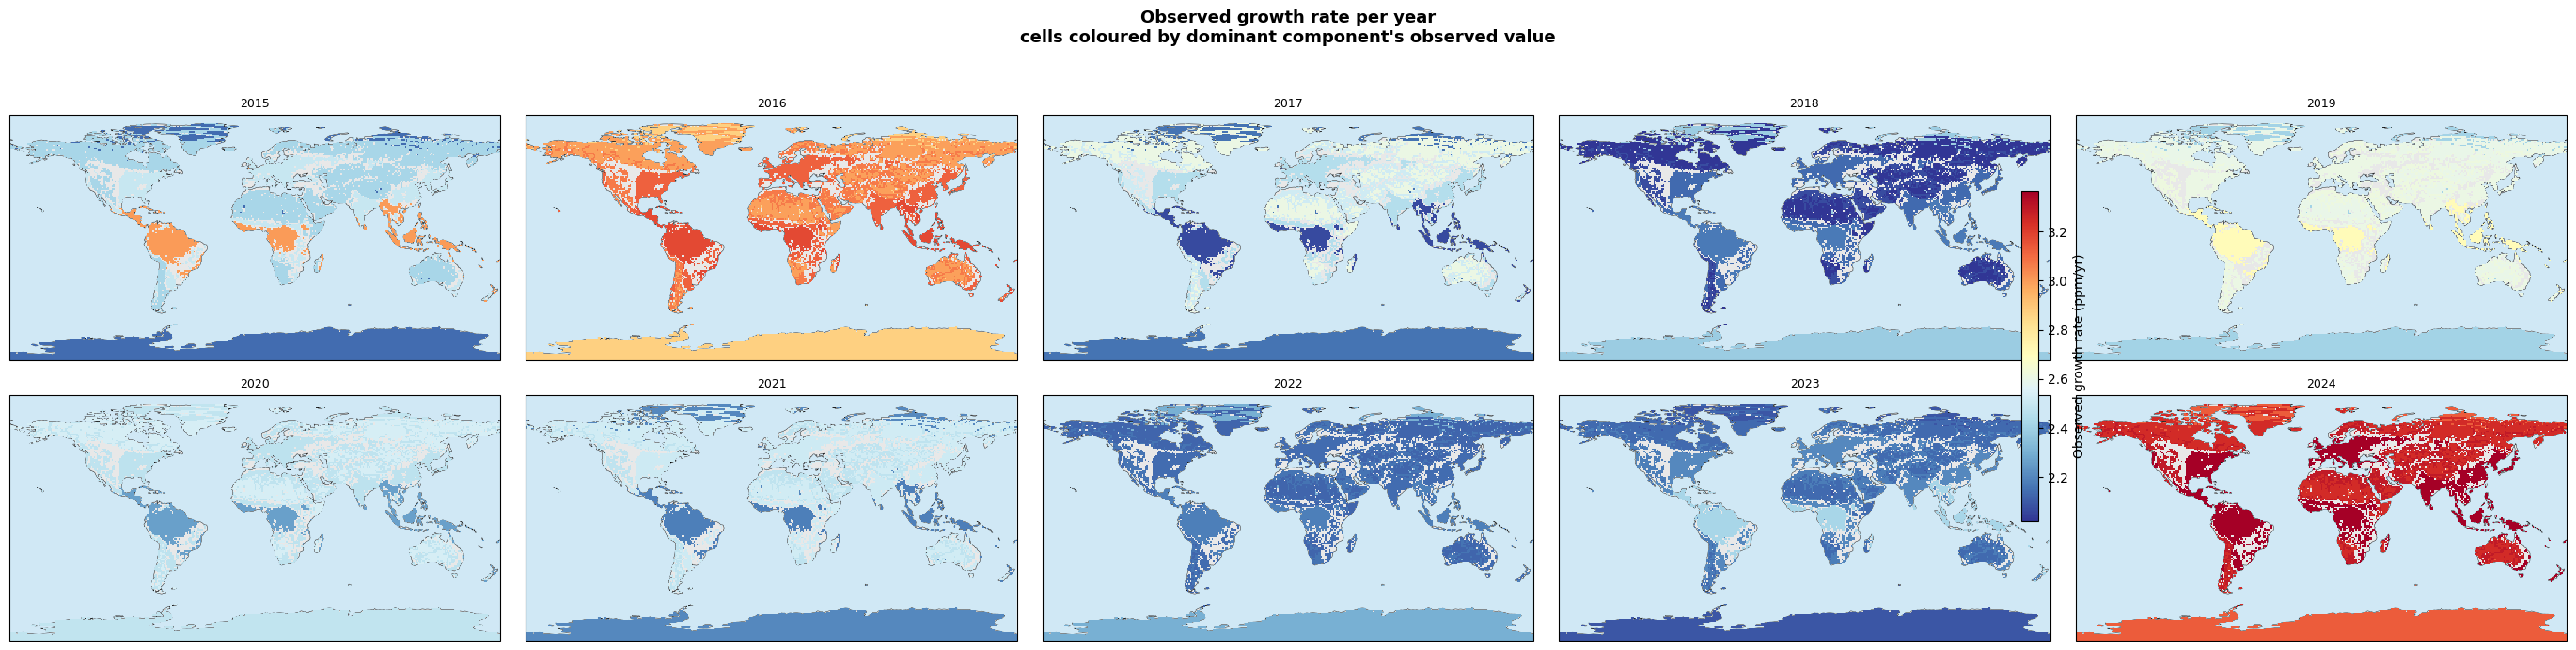

Saved → figures/co_occ_nospo_obs_maps_yearly.png


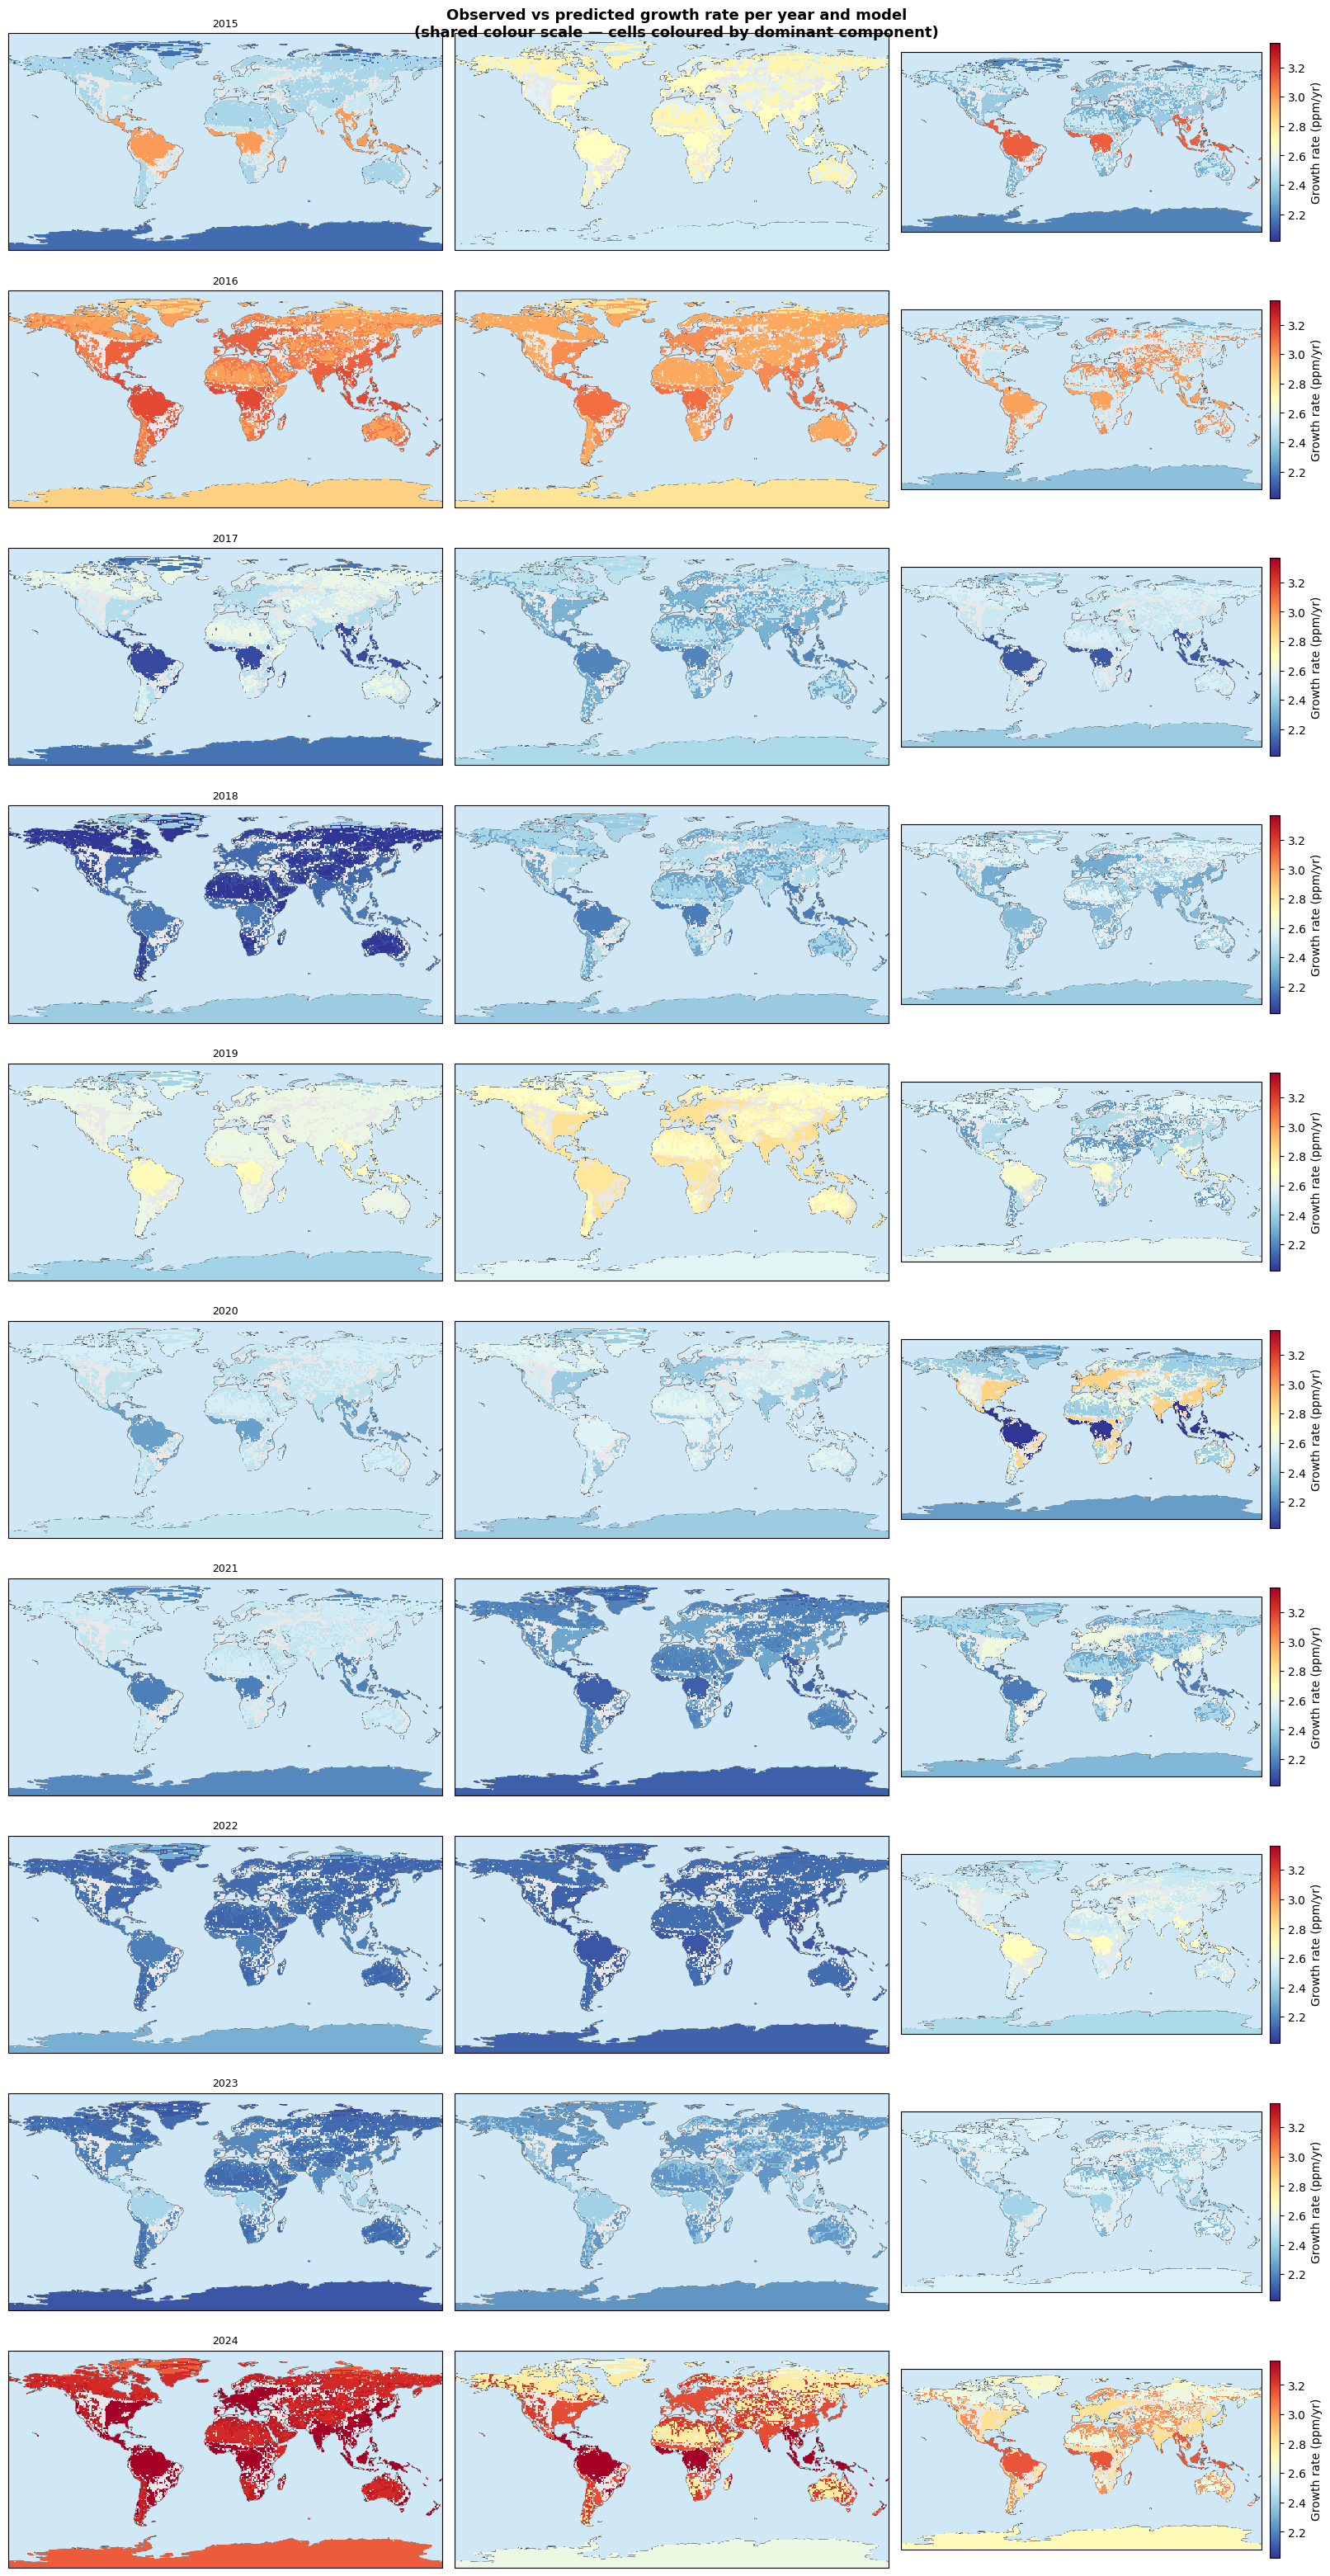

Saved → figures/co_occ_nospo_obs_vs_pred_maps_grid.png


In [37]:
# obs_map, vmin_obs, vmax_obs, cmap, _pcolormesh_map, LON2D, LAT2D, HAS_CARTOPY
# are all defined in §18 — run that cell first.

# ════════════════════════════════════════════════════════════════════════════════
# Figure 5 — Year-by-year observed growth rate
# ════════════════════════════════════════════════════════════════════════════════
ncols_y = 5
nrows_y = int(np.ceil(n_yr / ncols_y))

if HAS_CARTOPY:
    import cartopy.crs as ccrs
    proj  = ccrs.PlateCarree()
    fig5, axes5 = plt.subplots(nrows_y, ncols_y,
                               figsize=(5.5*ncols_y, 3.8*nrows_y),
                               subplot_kw={"projection": proj})
else:
    fig5, axes5 = plt.subplots(nrows_y, ncols_y,
                               figsize=(5.5*ncols_y, 3.5*nrows_y))
axes5 = np.atleast_2d(axes5).ravel()

for yi, year in enumerate(years):
    im = _pcolormesh_map(axes5[yi], obs_map[yi],
                         str(year), vmin_obs, vmax_obs, cmap, show_cbar=False)

for j in range(n_yr, len(axes5)):
    axes5[j].set_visible(False)

fig5.colorbar(im, ax=axes5[:n_yr], orientation="vertical",
              label="Observed growth rate (ppm/yr)", shrink=0.6, pad=0.02)
fig5.suptitle("Observed growth rate per year\n"
              "cells coloured by dominant component's observed value",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "co_occ_nospo_obs_maps_yearly.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/co_occ_nospo_obs_maps_yearly.png")

# ════════════════════════════════════════════════════════════════════════════════
# Figure 6 — Side-by-side: observed | Model A | Model B for each year
# ════════════════════════════════════════════════════════════════════════════════
n_panels = 3 if HAS_SOI else 2
panel_data  = [("Observed",  obs_map)]
panel_names = ["Observed"]
if HAS_SOI:
    panel_data.append(("Model A",  pred_map_A))
    panel_names.append("Model A (emis+SOI)")
panel_data.append(("Model B",  pred_map_B))
panel_names.append("Model B (emis+GOSIF)")

if HAS_CARTOPY:
    fig6, axes6 = plt.subplots(n_yr, n_panels,
                               figsize=(5.5*n_panels, 3.2*n_yr),
                               subplot_kw={"projection": proj})
else:
    fig6, axes6 = plt.subplots(n_yr, n_panels,
                               figsize=(5.5*n_panels, 3.0*n_yr))
axes6 = np.atleast_2d(axes6)

for col_i, (label, maps) in enumerate(panel_data):
    axes6[0, col_i].set_title(label, fontsize=11, fontweight="bold", pad=8)

for yi, year in enumerate(years):
    for col_i, (label, maps) in enumerate(panel_data):
        show_cb = (col_i == n_panels - 1)
        _pcolormesh_map(axes6[yi, col_i], maps[yi],
                        str(year) if col_i == 0 else "",
                        vmin_obs, vmax_obs, cmap, show_cbar=show_cb)
        if col_i == 0:
            # Year label on the left
            axes6[yi, col_i].set_ylabel(str(year), fontsize=9, labelpad=4)

fig6.suptitle("Observed vs predicted growth rate per year and model\n"
              "(shared colour scale — cells coloured by dominant component)",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "co_occ_nospo_obs_vs_pred_maps_grid.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/co_occ_nospo_obs_vs_pred_maps_grid.png")


---
## Report figures — Predictor contribution decomposition (no intercept)

Publication-quality version of §14. The stacked bars show only the two predictor
contributions — **β_E · E_z** (emission) and **β₂ · P_z** (SOI or GOSIF) — without
the intercept β₀, so the bars represent the year-to-year variation explained by each
driver rather than the absolute growth-rate level.

The observed time series (black) and full model prediction (dashed) are kept as
reference lines so the fit quality remains visible.


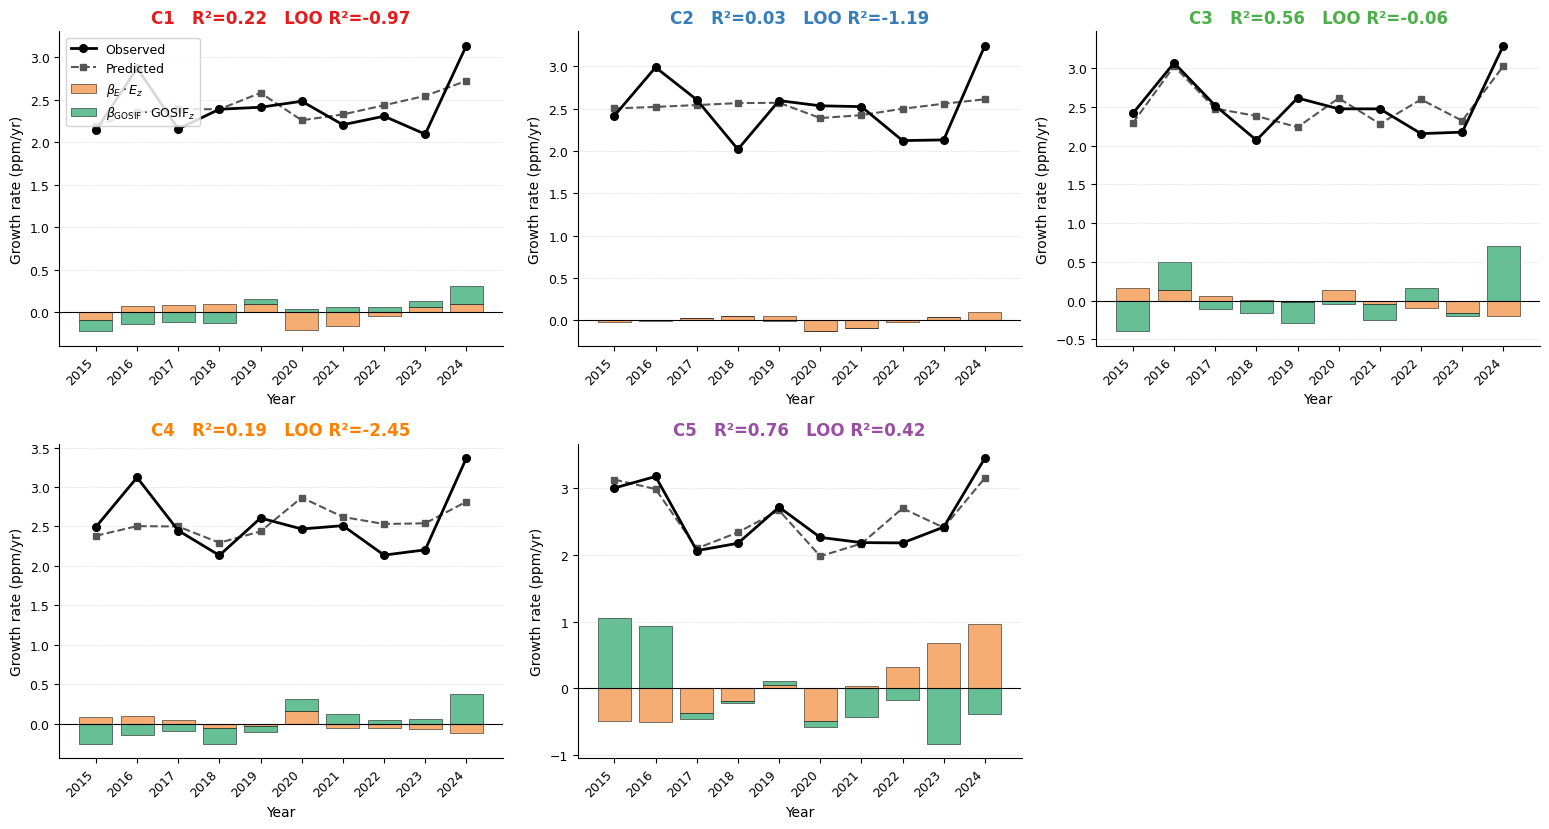

Saved → figures/report_decomp_no_intercept_model_B.png


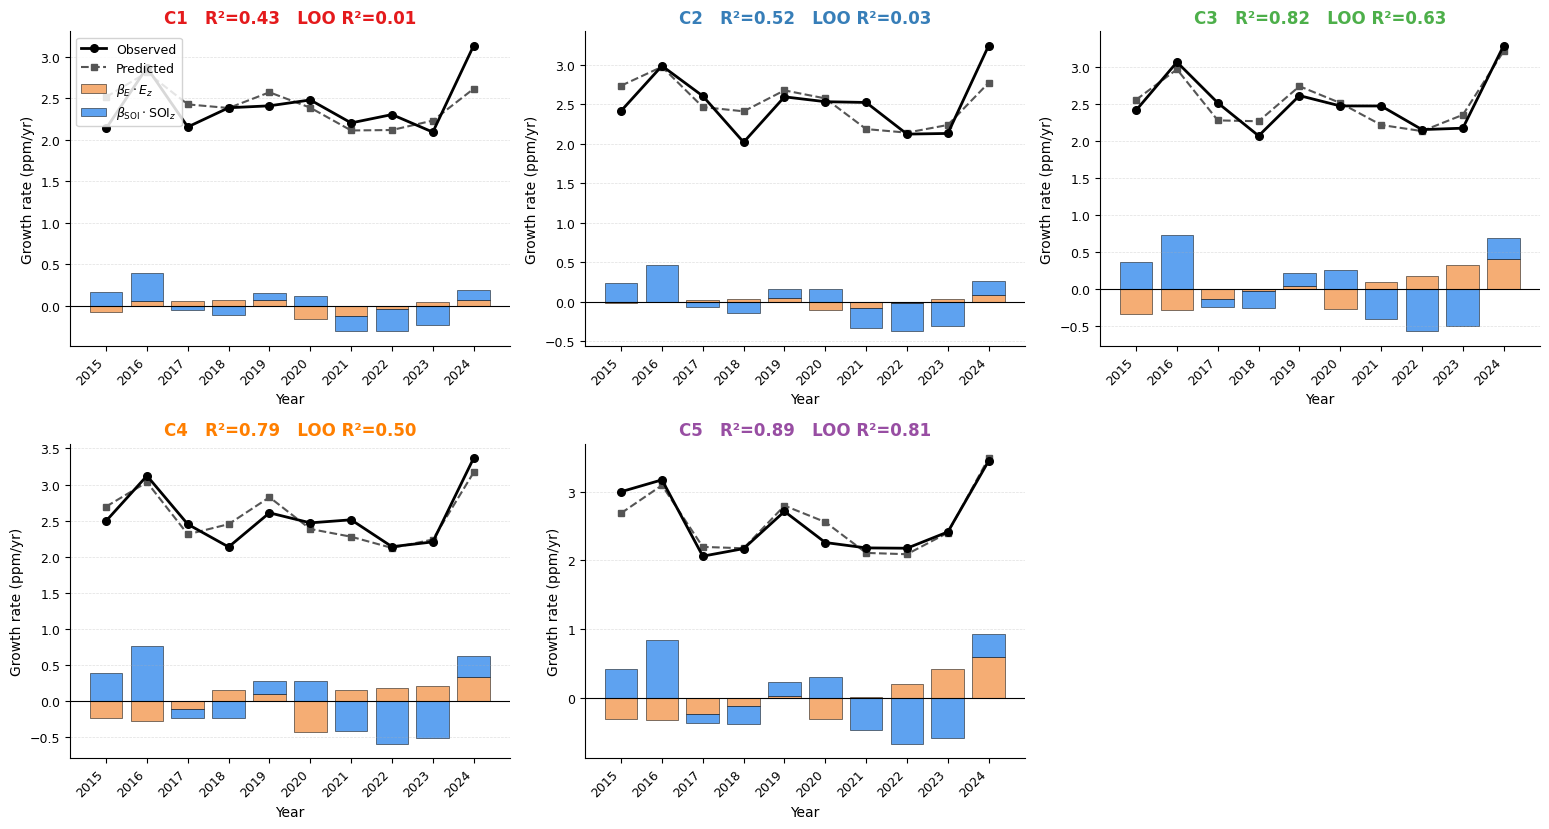

Saved → figures/report_decomp_no_intercept_model_A.png


In [40]:
def decomp_plot_no_intercept(results, preds_full, x2_z_dict,
                              x2_label, x2_color,
                              model_tag, save_name):
    """
    Stacked-bar predictor decomposition for report figures.
    Bars show only β_E·E_z and β₂·P_z (intercept omitted).
    Observed (black) and full predicted (grey dashed) are overlaid as reference lines.
    """
    FONT_TITLE  = 12
    FONT_AXIS   = 10
    FONT_TICK   = 9
    FONT_LEGEND = 9

    n_cl  = len(COMPONENTS)
    ncols = min(n_cl, 3)
    nrows = int(np.ceil(n_cl / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5.2*ncols, 4.2*nrows),
                             squeeze=False)

    emission_color = "#f4a261"   # warm orange — emission
    handles_done   = False

    for ci, comp in enumerate(COMPONENTS):
        ax  = axes[ci // ncols][ci % ncols]
        col = COMP_COLORS[comp]
        r   = results[comp]

        if np.isnan(r["beta0"]):
            ax.text(0.5, 0.5, "not fitted",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=FONT_AXIS, color="grey")
            continue

        b_e  = r["beta1"] * emission_z[comp]
        b_p2 = r["beta2"] * x2_z_dict[comp]

        parts = [
            (r"$\beta_E \cdot E_z$",  b_e,  emission_color),
            (x2_label,                  b_p2, x2_color),
        ]

        bottom_pos = np.zeros(len(years))
        bottom_neg = np.zeros(len(years))

        for part_label, vals, part_col in parts:
            pos = vals >= 0
            kw  = dict(color=part_col, edgecolor="k", linewidth=0.4, alpha=0.88)
            # Label only the first bar call so the legend shows each entry once
            ax.bar(years[ pos],  vals[ pos], bottom=bottom_pos[ pos],
                   label=part_label, **kw)
            ax.bar(years[~pos],  vals[~pos], bottom=bottom_neg[~pos],
                   label="_nolegend_", **kw)
            bottom_pos[ pos] += vals[ pos]
            bottom_neg[~pos] += vals[~pos]

        # Reference lines
        ax.plot(years, target[comp], "o-",
                color="k", linewidth=2, markersize=5.5,
                zorder=5, label="Observed")
        ax.plot(years, preds_full[comp], "s--",
                color="#555555", linewidth=1.5, markersize=4,
                zorder=4, label="Predicted")

        ax.axhline(0, color="k", linewidth=0.8, zorder=3)

        ax.set_xticks(years)
        ax.set_xticklabels(years, rotation=45, ha="right", fontsize=FONT_TICK)
        ax.tick_params(axis="y", labelsize=FONT_TICK)

        r2_str   = f"R²={r['r2']:.2f}"
        loo_str  = f"LOO R²={r['loo_r2']:.2f}" if not np.isnan(r["loo_r2"]) else ""
        ax.set_title(f"{COMP_LABELS[comp]}   {r2_str}   {loo_str}",
                     fontsize=FONT_TITLE, fontweight="bold", color=col, pad=6)
        ax.set_ylabel("Growth rate (ppm/yr)", fontsize=FONT_AXIS)
        ax.set_xlabel("Year", fontsize=FONT_AXIS)

        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linewidth=0.5, alpha=0.4, linestyle="--")

        if not handles_done:
            ax.legend(fontsize=FONT_LEGEND, loc="upper left",
                      frameon=True, framealpha=0.85, edgecolor="#cccccc")
            handles_done = True

    for ci in range(n_cl, nrows * ncols):
        axes[ci // ncols][ci % ncols].set_visible(False)

    #fig.suptitle(f"Predictor contributions — {model_tag}",
    #             fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / save_name, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved → figures/{save_name}")


# ── Model B: emission + GOSIF ─────────────────────────────────────────────────
decomp_plot_no_intercept(
    results_B, preds_B_full,
    gosif_z,
    x2_label  = r"$\beta_{\mathrm{GOSIF}} \cdot \mathrm{GOSIF}_z$",
    x2_color  = "#52b788",   # green — GOSIF / biosphere
    model_tag = "Model B (emission + GOSIF)",
    save_name = "report_decomp_no_intercept_model_B.png",
)

# ── Model A: emission + SOI ───────────────────────────────────────────────────
if HAS_SOI:
    soi_z_dict = {comp: soi_z for comp in COMPONENTS}
    decomp_plot_no_intercept(
        results_A, preds_A_full,
        soi_z_dict,
        x2_label  = r"$\beta_{\mathrm{SOI}} \cdot \mathrm{SOI}_z$",
        x2_color  = "#4895ef",   # blue — SOI / ENSO
        model_tag = "Model A (emission + SOI)",
        save_name = "report_decomp_no_intercept_model_A.png",
    )
else:
    print("Model A skipped (no SOI file).")


---
## Report figures — Per-component files (no suptitle)

Saves each component panel from the report decomposition figures as its own
separate PDF file. The suptitle is excluded because the crop is taken from the
individual axes bounding box, which does not extend to the figure-level title.

Output filenames follow the pattern:
`report_decomp_no_intercept_model_B_C1.pdf`, `…_C2.pdf`, etc.

> **Requires §20 (Report figures) to have been run first** so that `fig`, `axes`,
> and the layout are already in memory.


In [41]:
def save_components_individually(results, preds_full, x2_z_dict,
                                 x2_label, x2_color,
                                 model_tag, save_name):
    """
    Re-draws the decomposition figure and saves each component panel
    as a separate PDF, cropped tightly to that axes (suptitle excluded).
    """
    FONT_TITLE  = 12
    FONT_AXIS   = 10
    FONT_TICK   = 9
    FONT_LEGEND = 9

    n_cl  = len(COMPONENTS)
    ncols = min(n_cl, 3)
    nrows = int(np.ceil(n_cl / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5.2*ncols, 4.2*nrows),
                             squeeze=False)

    emission_color = "#f4a261"
    handles_done   = False

    for ci, comp in enumerate(COMPONENTS):
        ax  = axes[ci // ncols][ci % ncols]
        col = COMP_COLORS[comp]
        r   = results[comp]

        if np.isnan(r["beta0"]):
            ax.text(0.5, 0.5, "not fitted",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=FONT_AXIS, color="grey")
            continue

        b_e  = r["beta1"] * emission_z[comp]
        b_p2 = r["beta2"] * x2_z_dict[comp]

        parts = [
            (r"$\beta_E \cdot E_z$", b_e,  emission_color),
            (x2_label,                 b_p2, x2_color),
        ]

        bottom_pos = np.zeros(len(years))
        bottom_neg = np.zeros(len(years))

        for part_label, vals, part_col in parts:
            pos = vals >= 0
            kw  = dict(color=part_col, edgecolor="k", linewidth=0.4, alpha=0.88)
            ax.bar(years[ pos], vals[ pos], bottom=bottom_pos[ pos],
                   label=part_label, **kw)
            ax.bar(years[~pos], vals[~pos], bottom=bottom_neg[~pos],
                   label="_nolegend_", **kw)
            bottom_pos[ pos] += vals[ pos]
            bottom_neg[~pos] += vals[~pos]

        ax.plot(years, target[comp], "o-",
                color="k", linewidth=2, markersize=5.5, zorder=5, label="Observed")
        ax.plot(years, preds_full[comp], "s--",
                color="#555555", linewidth=1.5, markersize=4, zorder=4, label="Predicted")

        ax.axhline(0, color="k", linewidth=0.8, zorder=3)
        ax.set_xticks(years)
        ax.set_xticklabels(years, rotation=45, ha="right", fontsize=FONT_TICK)
        ax.tick_params(axis="y", labelsize=FONT_TICK)

        r2_str  = f"R²={r['r2']:.2f}"
        loo_str = f"LOO R²={r['loo_r2']:.2f}" if not np.isnan(r["loo_r2"]) else ""
        ax.set_title(f"{COMP_LABELS[comp]}   {r2_str}   {loo_str}",
                     fontsize=FONT_TITLE, fontweight="bold", color=col, pad=6)
        ax.set_ylabel("Growth rate (ppm/yr)", fontsize=FONT_AXIS)
        ax.set_xlabel("Year", fontsize=FONT_AXIS)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linewidth=0.5, alpha=0.4, linestyle="--")

        if not handles_done:
            ax.legend(fontsize=FONT_LEGEND, loc="upper left",
                      frameon=True, framealpha=0.85, edgecolor="#cccccc")
            handles_done = True

    for ci in range(n_cl, nrows * ncols):
        axes[ci // ncols][ci % ncols].set_visible(False)

    plt.tight_layout()

    # ── Finalise layout so bounding boxes are accurate ────────────────────────
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    stem     = Path(save_name).stem

    for ci, comp in enumerate(COMPONENTS):
        ax = axes[ci // ncols][ci % ncols]
        if not ax.get_visible():
            continue
        bbox = ax.get_tightbbox(renderer).transformed(
            fig.dpi_scale_trans.inverted()
        )
        out_path = FIGURE_DIR / f"{stem}_{COMP_LABELS[comp]}.pdf"
        fig.savefig(out_path, bbox_inches=bbox)
        print(f"Saved → figures/{stem}_{COMP_LABELS[comp]}.pdf")

    plt.close(fig)


# ── Model B: emission + GOSIF ─────────────────────────────────────────────────
save_components_individually(
    results_B, preds_B_full,
    gosif_z,
    x2_label  = r"$\beta_{{\mathrm{{GOSIF}}}} \cdot \mathrm{{GOSIF}}_z$",
    x2_color  = "#52b788",
    model_tag = "Model B (emission + GOSIF)",
    save_name = "report_decomp_no_intercept_model_B.pdf",
)

# ── Model A: emission + SOI ───────────────────────────────────────────────────
if HAS_SOI:
    soi_z_dict = {comp: soi_z for comp in COMPONENTS}
    save_components_individually(
        results_A, preds_A_full,
        soi_z_dict,
        x2_label  = r"$\beta_{{\mathrm{{SOI}}}} \cdot \mathrm{{SOI}}_z$",
        x2_color  = "#4895ef",
        model_tag = "Model A (emission + SOI)",
        save_name = "report_decomp_no_intercept_model_A.pdf",
    )
else:
    print("Model A skipped (no SOI file).")


Saved → figures/report_decomp_no_intercept_model_B_C1.pdf
Saved → figures/report_decomp_no_intercept_model_B_C2.pdf
Saved → figures/report_decomp_no_intercept_model_B_C3.pdf
Saved → figures/report_decomp_no_intercept_model_B_C4.pdf
Saved → figures/report_decomp_no_intercept_model_B_C5.pdf
Saved → figures/report_decomp_no_intercept_model_A_C1.pdf
Saved → figures/report_decomp_no_intercept_model_A_C2.pdf
Saved → figures/report_decomp_no_intercept_model_A_C3.pdf
Saved → figures/report_decomp_no_intercept_model_A_C4.pdf
Saved → figures/report_decomp_no_intercept_model_A_C5.pdf


## 17. Interpretation notes

- **β_E** is the association between the **raw** component-mean growth rate and
  standardised local emission anomalies within that component.  Because the global
  background CO₂ trend is **not** removed here (no SPO subtraction), the intercept
  β₀ now also absorbs the mean growth rate level for each component.
- **β_SOI (Model A)** captures the ENSO signal relative to the raw growth rate.
  The global CO₂ background rise can inflate or deflate this coefficient compared with
  the SPO-referenced version; compare with the SPO notebook to isolate the local signal.
- **β_GOSIF (Model B)** captures the biospheric uptake signal without removing the
  background, so the coefficient may be attenuated if photosynthesis is correlated with
  the long-term CO₂ trend.
- **LOO R²** is the honest out-of-sample metric with only 10 years of data.  A negative
  LOO R² means the model is worse than a constant predictor out-of-sample.
- Because components can overlap, the component-level time series are not independent.
- To isolate purely local signals, compare results with
  `co_occurrence_component_ols_regression.ipynb` where the SPO reference is subtracted.
